
# Predicting Child Stunting Growth in Kenya

## Problem Statement

Kenyan children under five are classified into stunting severity categories
— **severe stunting**, **moderate stunting**, or **normal growth** — based
on WHO height-for-age z-score (HAZ) thresholds of -3 SD and -2 SD, using
household, maternal, and child-health variables from the Kenya Demographic
and Health Survey Children's Recode. Predictors include region, residence
type, mother's education, household wealth index, drinking water source,
toilet facility, birth order and spacing, birth weight, breastfeeding
duration, and antenatal care history.

This is framed, and evaluated, primarily as a **classification** task: the
macro-averaged F1 score is the primary metric (chosen to weight the rare
severe-stunting class equally with the majority normal-growth class),
reported alongside one-vs-rest ROC-AUC and per-class precision/recall. As a
secondary, diagnostic view, the notebook also fits regression models against
the underlying continuous HAZ z-score itself, scored with RMSE, R², and MAE
— useful for understanding how precisely the predictors track HAZ as a
number, but not a replacement for the classification models, since a
discrete severity label is what a health worker ultimately acts on.

## The Problem

Stunting — being too short for one's age because of chronic undernutrition —
still affects roughly one in five children under five in Kenya. A stunted
child faces lifelong risks: weaker immunity, slower cognitive development,
and lower earning potential as an adult. Health workers and parents need a
reliable way to spot which children are stunted, and how severely, early
enough to act — but with limited time and resources, they cannot manually
review every household's full survey record to catch every at-risk child.

## Our Solution

We build a machine learning model that takes a child's household, maternal,
and health-history information and classifies their growth status as
**severe stunting**, **moderate stunting**, or **normal growth**. Beyond the
prediction itself, each outcome is paired with practical guidance: children
flagged as stunted (severe or moderate) receive diet and care recommendations
aimed at correcting growth faltering, while children predicted to be growing
normally receive guidance to continue their current feeding practices. The
goal is a tool that medical practitioners and parents can use to decide, at a
glance, whether a child's diet needs to change and how.

## Data Source

The data comes from the **Kenya Demographic and Health Survey (KDHS)**,
specifically its **Children's Recode** file — a nationally representative
household survey that records one row per live birth reported by an
interviewed woman (`bidx` = birth order index within her birth history,
`caseid` identifies the mother). For children under five it captures health,
nutrition, immunization, and anthropometric (height/weight) measurements
alongside household and maternal background variables. The Children's Recode
was originally distributed as a Stata file (`KEKR8CFL.DTA`, with column
layout described in `KEKR8CFL.DCT`); we use those two files only once, up
front, to decode Stata's numeric variable and value codes into their
plain-English meanings — from that point on we work entirely from CSV.

**Inputs used**

| File | Role |
|---|---|
| `child_recode_raw.csv` | the raw data we are cleaning (19,530 rows × 1,312 columns) |
| `variable_labels.csv` | plain-English description for every variable code (`v106` -> "Highest educational level"), used to understand and rename the columns we keep |



In [ ]:

# --- Imports -----------------------------------------------------------
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat  # only used to read METADATA (variable/value labels) from the .dta file
from sklearn.exceptions import UndefinedMetricWarning

# In a few cross-validation folds, "severe stunting" (the rarest class) can
# end up with zero predicted samples for a weaker model; sklearn's macro
# precision/recall then emits a warning and reports 0.0 for that class,
# which is the mathematically correct (if uninformative) value - suppressed
# here so it doesn't clutter otherwise-successful cell output.
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

# --- File locations ------------------------------------------------------
# Adjust these if your files live somewhere else. All four inputs are expected
# to sit in the same folder as this notebook by default.
DATA_DIR = Path(".")
RAW_CSV        = DATA_DIR / "child_recode_raw.csv"
LABELS_CSV     = DATA_DIR / "variable_labels.csv"
DTA_FILE       = DATA_DIR / "KEKR8CFL.DTA"

OUT_DIR = Path("cleaned_output")
OUT_DIR.mkdir(exist_ok=True)



# Part 1: Data Cleaning and Preprocessing

This part takes the raw export and turns it into a trustworthy, analysis-ready
table: fixing identifiers, removing dead columns, converting DHS placeholder
codes to real `NaN`s, right-sizing dtypes, and narrowing down to the variables
the stunting model actually needs.



## 1. Load the raw data and the variable-label dictionary


In [ ]:

# The raw export only has two genuinely text columns (caseid, v000); every
# other one of the 1,312 columns is numeric (DHS encodes everything -
# including categories - as integer codes). We let pandas infer dtypes on
# the first pass and fix them up deliberately in later steps.
df = pd.read_csv(RAW_CSV, low_memory=False)

# variable -> plain-English description, e.g. "v106" -> "Highest educational level"
var_labels = pd.read_csv(LABELS_CSV).set_index("variable")["label"].to_dict()

print(f"Raw data: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Variable descriptions loaded for {len(var_labels):,} variables")
df.head(3)


Raw data: 19,530 rows x 1,312 columns
Variable descriptions loaded for 1,312 variables


,caseid,bidx,v000,v001,v002,v003,v004,v005,v006,v007,v008,v008a,v009,v010,v011,v012,v013,v014,v015,v016,v017,v018,v019,v019a,v020,v021,v022,v023,v024,v025,...,s446,s454a,idx95,s509y,sd509y,sm509y,sy509y,s528a,s509d,sd509d,sm509d,sy509d,s607aa,s607ba,s612q,s612r,s612s,s612t,s615e,s621a,s621b,s626q,s626r,s626s,s626t,s631a,s631b,s631c,s631l,s631m
0,1 4 2,1,KE8,1,4,2,1,1296049,4,2022,1468,44676,10,1987,1054,34,4,3,1,25,1405,17,64,2,0,1,1,1,1,1,...,2.0,203.0,1.0,0.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 13 2,1,KE8,1,13,2,1,1296049,4,2022,1468,44679,12,1982,996,39,5,1,1,28,1405,17,64,2,0,1,1,1,1,1,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 26 2,1,KE8,1,26,2,1,1296049,4,2022,1468,44676,11,1993,1127,28,3,1,1,25,1405,17,64,2,0,1,1,1,1,1,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## 2. Initial audit

Before changing anything, get a baseline: are there duplicate records, how
much is already missing, and how big is the file in memory.


In [ ]:

# --- Duplicate check ------------------------------------------------------
# Each row should be a unique (mother, birth) pair.
n_dupes = df.duplicated(subset=["caseid", "bidx"]).sum()
print(f"Duplicate (caseid, bidx) pairs: {n_dupes}")

# --- Baseline missingness & memory ----------------------------------------
baseline_missing_cells = df.isnull().sum().sum()
baseline_missing_pct = 100 * baseline_missing_cells / df.size
baseline_memory_mb = df.memory_usage(deep=True).sum() / 1e6

print(f"Missing cells (raw, before recoding placeholder codes): "
      f"{baseline_missing_cells:,} ({baseline_missing_pct:.1f}% of all cells)")
print(f"Memory usage: {baseline_memory_mb:.1f} MB")


Duplicate (caseid, bidx) pairs: 0


Missing cells (raw, before recoding placeholder codes): 16,083,722 (62.8% of all cells)
Memory usage: 206.9 MB



## 3. Build a data dictionary from the Stata metadata

The `.dta` file's *metadata* (not its data rows) tells us, for every
categorical variable, exactly what each numeric code means — including
which codes are placeholders like "don't know" or "flagged case" rather
than real answers. We read this once with `pyreadstat` using
`metadataonly=True`, which is essentially instant since it never touches
the 28 MB of actual row data.


In [ ]:

_, meta = pyreadstat.read_dta(str(DTA_FILE), metadataonly=True)

# variable -> {code: "meaning"}, e.g. "b4" -> {1: "male", 2: "female"}
value_labels = meta.variable_value_labels

print(f"Variables with a value-label set: {len(value_labels):,} / {len(meta.column_names):,}")

# Peek at a couple of examples to see the kind of thing we're working with
for v in ["b4", "hw70", "m19"]:
    print(f"  {v}: {value_labels.get(v)}")


Variables with a value-label set: 1,206 / 1,312
  b4: {1: 'male', 2: 'female'}
  hw70: {9996: 'height out of plausible limits', 9997: 'age in days out of plausible limits', 9998: 'flagged cases'}
  m19: {9996: 'not weighed at birth', 9998: "don't know"}


In [ ]:

# Persist a full data dictionary (description + value labels where they exist)
# so anyone using the cleaned CSV later can look up what a column/code means
# without needing the original .dta file.
data_dictionary = {}
for col in df.columns:
    data_dictionary[col] = {
        "label": var_labels.get(col, ""),
        "value_labels": value_labels.get(col, {}),
    }

with open(OUT_DIR / "data_dictionary.json", "w") as f:
    json.dump(data_dictionary, f, indent=2)

print(f"Data dictionary written for {len(data_dictionary):,} columns -> "
      f"{OUT_DIR / 'data_dictionary.json'}")


Data dictionary written for 1,312 columns -> cleaned_output/data_dictionary.json



## 4. Clean identifier columns

`caseid` is a fixed-width string (it packs cluster/household/line-number
together) and can pick up leading/trailing spaces when exported to CSV.
`v000` (country + survey phase code) is the other text column. Both just
need whitespace stripped. We also build a single tidy `child_id` key.


In [ ]:

df["caseid"] = df["caseid"].astype(str).str.strip()
df["v000"]   = df["v000"].astype(str).str.strip()

# A convenient, unambiguous per-child key: mother's caseid + this birth's index
child_id = (df["caseid"] + "_" + df["bidx"].astype("Int64").astype(str)).rename("child_id")
df = pd.concat([child_id, df], axis=1)

assert df["child_id"].is_unique, "child_id should uniquely identify each row"
print("child_id created and confirmed unique.")
df[["child_id", "caseid", "bidx"]].head(3)


child_id created and confirmed unique.


,child_id,caseid,bidx
0,1 4 2_1,1 4 2,1
1,1 13 2_1,1 13 2,1
2,1 26 2_1,1 26 2,1



## 5. Drop columns that carry no information

Two kinds of "dead weight" columns show up in DHS exports:

- **Fully empty columns** — usually variables not fielded in this particular
  survey (e.g. modules asked in some country-phases but not others).
- **Constant columns** — every non-missing row has the exact same value
  (e.g. a survey-phase code, always `"KE8"`). They carry zero variance, so
  they add size without adding analytical value.

We drop both, but log exactly what we dropped (and, for constants, what the
one value was) so nothing disappears silently.


In [ ]:

protected_cols = {"child_id", "caseid", "bidx"}  # never drop identifiers

fully_null_cols = [c for c in df.columns if c not in protected_cols and df[c].isnull().all()]

constant_cols = [
    c for c in df.columns
    if c not in protected_cols and c not in fully_null_cols and df[c].nunique(dropna=True) <= 1
]

dropped_log = []
for c in fully_null_cols:
    dropped_log.append({"column": c, "reason": "100% empty", "label": var_labels.get(c, "")})
for c in constant_cols:
    only_value = df[c].dropna().iloc[0] if df[c].notna().any() else None
    dropped_log.append({
        "column": c, "reason": f"constant (always {only_value!r})", "label": var_labels.get(c, "")
    })

dropped_df = pd.DataFrame(dropped_log)

cols_to_drop = fully_null_cols + constant_cols
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(fully_null_cols)} fully-empty columns and "
      f"{len(constant_cols)} constant columns ({len(cols_to_drop)} total).")
print(f"Remaining columns: {df.shape[1]:,}")
dropped_df.to_csv(OUT_DIR / "dropped_columns_log.csv", index=False)
dropped_df.head(10)


Dropped 354 fully-empty columns and 51 constant columns (405 total).
Remaining columns: 908


,column,reason,label
0,v026,100% empty,NA - De facto place of residence
1,v029,100% empty,NA - Keyer identification
2,v031,100% empty,NA - Field editor
3,v032,100% empty,NA - Office editor
4,v048,100% empty,NA - Team supervisor
5,v103,100% empty,NA - Childhood place of residence
6,v134,100% empty,NA - De facto place of residence
7,v156,100% empty,NA - Ever participated in a literacy program o...
8,v167,100% empty,NA - Number of trips in last 12 months
9,v168,100% empty,NA - Away for more than one month in last 12 m...



## 6. Recode DHS placeholder codes to proper `NaN`

DHS variables use reserved numeric codes for non-answers instead of a blank
cell — for example `hw70` (height-for-age z-score) uses `9996` = "height out
of plausible limits", `9997` = "age in days out of plausible limits", and
`9998` = "flagged cases". Left as numbers, these would silently corrupt any
average, histogram, or model fit on that column.

Rather than guessing at "big numbers look like missing codes", we use the
actual value-label text pulled from the `.dta` metadata in step 3 and match
it against a set of known missingness phrases. This only converts codes
that are *documented* as non-substantive — real category codes (like
`v106` = 0 "no education") are left alone.


In [ ]:

# Phrases that reliably indicate "this code is not a real answer" in DHS codebooks.
MISSING_PATTERN = re.compile(
    r"\bmissing\b|not applicable|not present|\brefused\b|\bflagged\b|"
    r"plausible limits|don.?t know|not weighed|not measured|\binconsistent\b|"
    r"no response|not stated|not dejure",
    re.IGNORECASE,
)

# Build {column: {code: label}} for just the codes that match the pattern above
missing_code_map = {}
for col, labels in value_labels.items():
    if col not in df.columns:
        continue
    flagged = {code: text for code, text in labels.items() if MISSING_PATTERN.search(str(text))}
    if flagged:
        missing_code_map[col] = flagged

print(f"{len(missing_code_map):,} columns contain at least one documented missing/placeholder code.")


401 columns contain at least one documented missing/placeholder code.


In [ ]:

# Apply the recoding, keeping a full audit trail of exactly how many cells
# changed per column and per code.
recode_log = []
for col, flagged in missing_code_map.items():
    codes = list(flagged.keys())
    hit_counts = df[col].isin(codes)
    n_hits = int(hit_counts.sum())
    if n_hits == 0:
        continue
    for code, text in flagged.items():
        n = int((df[col] == code).sum())
        if n > 0:
            recode_log.append({
                "column": col, "code": code, "meaning": text, "n_cells_recoded": n,
            })
    df.loc[hit_counts, col] = np.nan

recode_log_df = pd.DataFrame(recode_log).sort_values("n_cells_recoded", ascending=False)
recode_log_df.to_csv(OUT_DIR / "missing_code_recode_log.csv", index=False)

print(f"Recoded {recode_log_df['n_cells_recoded'].sum():,} cells across "
      f"{recode_log_df['column'].nunique():,} columns to NaN.")
recode_log_df.head(15)


Recoded 22,094 cells across 332 columns to NaN.


,column,code,meaning,n_cells_recoded
67,v621,8,don't know,1389
92,m19a,0,not weighed,1266
90,m19,9996,not weighed at birth,1266
15,v379,98,don't know,1199
16,v380,8,don't know,1199
8,v244,8,don't know,654
6,v217,8,don't know,649
59,v529,997,inconsistent,600
2,v139,97,not dejure resident,538
7,v226,997,inconsistent,535



## 7. Confirm the effect: missingness before vs. after

A quick before/after comparison shows the recoding step actually surfaced
missingness that was previously hiding behind numeric placeholder codes.


In [ ]:

after_missing_cells = df.isnull().sum().sum()
after_missing_pct = 100 * after_missing_cells / df.size

comparison = pd.DataFrame({
    "stage": ["raw (blank cells only)", "after placeholder-code recoding"],
    "missing_cells": [baseline_missing_cells, after_missing_cells],
    "pct_of_all_cells": [round(baseline_missing_pct, 2), round(after_missing_pct, 2)],
})
comparison


,stage,missing_cells,pct_of_all_cells
0,raw (blank cells only),16083722,62.77
1,after placeholder-code recoding,8765073,49.43



## 8. Right-size data types

Now that missing values are proper `NaN`s rather than large placeholder
integers, we can shrink numeric columns to the smallest safe type. Columns
with any `NaN` need pandas's **nullable** integer type (`Int64`, capital I)
rather than plain `int64`, since plain numpy ints can't hold `NaN`.


In [ ]:

before_mb = df.memory_usage(deep=True).sum() / 1e6

for col in df.columns:
    if col in ("child_id", "caseid", "v000"):
        continue  # leave text columns alone
    series = df[col]
    if not pd.api.types.is_numeric_dtype(series):
        continue

    if (series.dropna() % 1 == 0).all():
        # Whole numbers -> nullable integer, sized to the observed range
        max_abs = series.abs().max()
        if pd.isna(max_abs):
            continue
        if max_abs < 2**7:
            dtype = "Int8"
        elif max_abs < 2**15:
            dtype = "Int16"
        elif max_abs < 2**31:
            dtype = "Int32"
        else:
            dtype = "Int64"
        df[col] = series.astype(dtype)
    else:
        # Genuine decimals (e.g. sample weights) -> float32 is ample precision here
        df[col] = series.astype("float32")

after_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory usage: {before_mb:.1f} MB -> {after_mb:.1f} MB "
      f"({100 * (1 - after_mb / before_mb):.0f}% smaller)")


Memory usage: 143.9 MB -> 40.0 MB (72% smaller)



## 9. Add human-readable labels for the most commonly used variables

Keeping the underlying columns numeric-coded matches how the DHS data is
normally shared and merged with companion files, but a handful of variables
get referenced constantly in child-health analysis. For just those, we add
a companion `<var>_label` column decoded straight from the value-label
dictionary, so they're readable without a lookup step.


In [ ]:

KEY_VARS_TO_DECODE = [
    "b4",     # sex of child
    "b5",     # child is alive
    "v106",   # mother's highest educational level
    "v190",   # wealth index quintile (combined)
    "v190a",  # wealth index quintile (urban/rural specific)
    "v024",   # region
    "v025",   # type of place of residence
    "v013",   # mother's age in 5-year groups
    "v113",   # source of drinking water
    "v116",   # type of toilet facility
    "h11",    # had diarrhea recently
    "h22",    # had fever in last two weeks
]

decoded_count = 0
for var in KEY_VARS_TO_DECODE:
    if var not in df.columns or var not in value_labels:
        continue
    label_map = value_labels[var]
    df[f"{var}_label"] = df[var].map(label_map)
    decoded_count += 1

print(f"Added readable *_label columns for {decoded_count} key variables.")
df[[v for pair in ((v, f"{v}_label") for v in KEY_VARS_TO_DECODE if v in df.columns)
      for v in pair]].head(5)


Added readable *_label columns for 12 key variables.


,b4,b4_label,b5,b5_label,v106,v106_label,v190,v190_label,v190a,v190a_label,v024,v024_label,v025,v025_label,v013,v013_label,v113,v113_label,v116,v116_label,h11,h11_label,h22,h22_label
0,1,male,1,yes,0,no education,4,richer,2,poorer,1,mombasa,1,urban,4,30-34,14,public tap/standpipe,22,pit latrine with slab,0,no,0,no
1,2,female,1,yes,2,secondary,5,richest,4,richer,1,mombasa,1,urban,5,35-39,12,piped to yard/plot,12,flush to septic tank,0,no,0,no
2,1,male,1,yes,2,secondary,4,richer,2,poorer,1,mombasa,1,urban,3,25-29,13,piped to neighbor,21,ventilated improved pit latrine (vip),0,no,0,no
3,2,female,1,yes,2,secondary,5,richest,4,richer,1,mombasa,1,urban,4,30-34,14,public tap/standpipe,21,ventilated improved pit latrine (vip),0,no,1,yes
4,1,male,1,yes,2,secondary,5,richest,3,middle,1,mombasa,1,urban,4,30-34,14,public tap/standpipe,21,ventilated improved pit latrine (vip),0,no,0,no



## 10. Sanity-check a few key variables

A quick range/consistency check on variables that matter most for child
health analysis. This isn't exhaustive (that would mean hand-checking all
~1,300 variables), but it catches the kind of gross problem worth knowing
about before analysis: e.g. z-scores outside their documented plausible
range, or a sex code that isn't 1/2.


In [ ]:

checks = []

# Anthropometric z-scores are stored *100 and should sit roughly in [-600, 600]
# once flagged/implausible codes have already been removed in step 6.
for zcol, zname in [("hw70", "height-for-age"), ("hw71", "weight-for-age"), ("hw72", "weight-for-height")]:
    if zcol in df.columns:
        out_of_range = df[zcol].dropna()
        bad = ((out_of_range < -600) | (out_of_range > 600)).sum()
        checks.append({"check": f"{zname} z-score ({zcol}) within [-6.00, 6.00] SD", "violations": int(bad)})

# Sex of child should only ever be 1 (male) or 2 (female)
if "b4" in df.columns:
    bad = (~df["b4"].isin([1, 2]) & df["b4"].notna()).sum()
    checks.append({"check": "b4 (sex of child) is 1 or 2", "violations": int(bad)})

# Child's current age in years should be non-negative and plausible (<= ~20 for a KR file)
if "b8" in df.columns:
    bad = ((df["b8"] < 0) | (df["b8"] > 20)).sum()
    checks.append({"check": "b8 (child's current age in years) within [0, 20]", "violations": int(bad)})

checks_df = pd.DataFrame(checks)
checks_df


,check,violations
0,"height-for-age z-score (hw70) within [-6.00, 6...",0
1,"weight-for-age z-score (hw71) within [-6.00, 6...",0
2,weight-for-height z-score (hw72) within [-6.00...,0
3,b4 (sex of child) is 1 or 2,0
4,"b8 (child's current age in years) within [0, 20]",0



## 11. Keep only the features listed in `features.docx`

The project's feature list (`features.docx`) specifies exactly one target
variable and a curated set of predictors for a child-stunting model. We
narrow the cleaned dataset down to just those columns before saving.

- **Target:** `hw70` (height-for-age z-score — the stunting outcome).
- **Predictors:** the child-, maternal-, household-, and illness-level
  variables listed in the document.
- `v455` is mentioned in the document itself as "consider if present in
  dataset" — it isn't one of this survey's columns, so it's skipped.
- We keep `child_id`, `caseid`, and `bidx` even though they aren't in the
  feature document, since they're the only way to identify each row —
  a feature table with no key isn't usable. We also keep the `_label`
  companion columns (e.g. `b4_label`) added in step 9 for any requested
  variable that has one, since those are just a readable version of a
  variable already on the list, not a new one.


In [ ]:

# Exactly the variables named in features.docx
TARGET_VAR = "hw70"

FEATURE_VARS = [
    # Child-level
    "hw1", "b4", "bord", "b0", "b11", "m18", "m19", "m19a",
    # Maternal / care-seeking
    "v106", "v133", "v437", "v438", "m14", "m13", "m45", "m4", "m5",
    # Household / socioeconomic
    "v190", "v113", "v116", "v025", "v024", "v151",
    # Health / illness
    "h11", "h33", "h10",
]

# v455 is called out in the document as "consider if present in dataset" —
# it isn't one of this survey's variables, so there's nothing to keep.
requested = [TARGET_VAR] + FEATURE_VARS
missing_from_data = [v for v in requested if v not in df.columns]
if missing_from_data:
    print(f"Note: not present in this dataset, skipped: {missing_from_data}")

# Identifiers we keep regardless (not "features", but required to use the table at all)
id_cols = [c for c in ["child_id", "caseid", "bidx"] if c in df.columns]

# Readable *_label companions for any requested variable that has one
label_cols = [f"{v}_label" for v in requested if f"{v}_label" in df.columns]

keep_cols = id_cols + [v for v in requested if v in df.columns] + label_cols
dropped_for_features = [c for c in df.columns if c not in keep_cols]

df = df[keep_cols]

print(f"Kept {len(keep_cols)} columns ({len(id_cols)} identifiers, "
      f"{len(requested) - len(missing_from_data)} requested features, {len(label_cols)} label companions).")
print(f"Dropped {len(dropped_for_features)} columns not on the features list.")
df.head(3)


Kept 38 columns (3 identifiers, 27 requested features, 8 label companions).
Dropped 882 columns not on the features list.


,child_id,caseid,bidx,hw70,hw1,b4,bord,b0,b11,m18,m19,m19a,v106,v133,v437,v438,m14,m13,m45,m4,m5,v190,v113,v116,v025,v024,v151,h11,h33,h10,b4_label,v106_label,v190_label,v113_label,v116_label,v025_label,v024_label,h11_label
0,1 4 2_1,1 4 2,1,362,8,1,4,0,92,2,4000,2,0,0,973,1614,5,5,1,95,7,4,14,22,1,1,1,0,0,<NA>,male,no education,richer,public tap/standpipe,pit latrine with slab,urban,mombasa,no
1,1 13 2_1,1 13 2,1,-11,36,2,5,0,30,<NA>,<NA>,<NA>,2,12,1028,1613,<NA>,<NA>,<NA>,<NA>,<NA>,5,12,12,1,1,1,0,<NA>,<NA>,female,secondary,richest,piped to yard/plot,flush to septic tank,urban,mombasa,no
2,1 26 2_1,1 26 2,1,-86,58,1,3,0,23,<NA>,<NA>,<NA>,2,12,660,1492,<NA>,<NA>,<NA>,<NA>,<NA>,4,13,21,1,1,1,0,<NA>,<NA>,male,secondary,richer,piped to neighbor,ventilated improved pit latrine (vip),urban,mombasa,no



## 12. Save the cleaned dataset and supporting files

Everything goes into `cleaned_output/`:

| File | Contents |
|---|---|
| `child_recode_clean.csv` | the cleaned dataset, narrowed to the `features.docx` variable list plus identifiers |
| `data_dictionary.json` | variable label + value-label lookup (kept for every column seen during cleaning, so it still documents dropped columns too) |
| `dropped_columns_log.csv` | every column removed in step 5, and why |
| `missing_code_recode_log.csv` | every placeholder code converted to `NaN` in step 6, and how many cells it affected |


In [ ]:

out_csv = OUT_DIR / "child_recode_clean.csv"
df.to_csv(out_csv, index=False)

print("Saved:")
print(f"  {out_csv}  ({df.shape[0]:,} rows x {df.shape[1]:,} columns)")
print(f"  {OUT_DIR / 'data_dictionary.json'}")
print(f"  {OUT_DIR / 'dropped_columns_log.csv'}")
print(f"  {OUT_DIR / 'missing_code_recode_log.csv'}")


Saved:
  cleaned_output/child_recode_clean.csv  (19,530 rows x 38 columns)
  cleaned_output/data_dictionary.json
  cleaned_output/dropped_columns_log.csv
  cleaned_output/missing_code_recode_log.csv



## 13. A human-readable version, for exploration and reporting

`child_recode_clean.csv` keeps DHS's numeric codes (`v106`, `v113`, ...)
because that's what Part 3's feature engineering and Part 4's encoding
need to work with. But codes aren't how anyone wants to *read* the data —
counties as numbers, education as 0-3, wealth as 1-5. This step builds a
companion table with descriptive column names and every category decoded
to its actual text (e.g. `v113 == 11` -> `source of drinking water ==
"piped into dwelling"`), for use in Part 2's exploratory analysis and any
reporting or presentation.

Two continuous measures also get converted to their natural units:
birth weight from grams-implied storage to kilograms, and the HAZ score
from *100-scaled storage to actual standard deviations — plus the
`stunting category` label from the severity scheme above.

This table is for humans, not `scikit-learn` — Parts 3-4 continue to work
from the coded version.


In [ ]:

HAZ_CATEGORY_BINS = [-6.01, -3, -2, 6.01]  # small buffer past the documented -6/6 endpoints so they're included
HAZ_CATEGORY_LABELS = ["Severe stunting", "Moderate stunting", "Normal growth"]

# variable -> descriptive column name
RENAME_MAP = {
    "child_id": "child id",
    "caseid": "case id",
    "v024": "region",
    "v025": "type of residence",
    "v106": "highest level of education",
    "v113": "source of drinking water",
    "v116": "type of toilet facility",
    "v151": "sex of household head",
    "v190": "wealth index",
    "b0": "child is twin",
    "b4": "sex of child",
    "bord": "birth order",
    "b11": "preceding birth interval (months)",
    "hw1": "child's age in months",
    "m18": "size of child at birth",
    "m4": "duration of breastfeeding",
    "m13": "month of pregnancy at first antenatal visit",
    "m14": "number of antenatal care visits",
    "m45": "took iron tablets during pregnancy",
    "h10": "had fever in last two weeks",
    "h11": "had diarrhea recently",
    "h33": "received vitamin a supplement",
}

# Variables in RENAME_MAP whose raw codes need decoding to text (the rest -
# birth order, age in months, preceding birth interval - are already plain numbers)
categorical_source_vars = [
    "v024", "v025", "v106", "v113", "v116", "v151", "v190",
    "b0", "b4", "m18", "m4", "m45", "h10", "h11", "h33",
]

labeled_df = df[list(RENAME_MAP.keys()) + ["m19", "hw70"]].copy()

for var in categorical_source_vars:
    labeled_df[var] = labeled_df[var].map(value_labels[var]).str.title()

# Natural units for the two continuous health measures
labeled_df["birth weight (kg)"] = labeled_df.pop("m19") / 1000
labeled_df["height-for-age z-score"] = labeled_df.pop("hw70") / 100
labeled_df["stunting category"] = pd.cut(
    labeled_df["height-for-age z-score"], bins=HAZ_CATEGORY_BINS, labels=HAZ_CATEGORY_LABELS
)

labeled_df = labeled_df.rename(columns=RENAME_MAP)

out_labeled_csv = OUT_DIR / "child_recode_labeled.csv"
labeled_df.to_csv(out_labeled_csv, index=False)

print(f"Saved: {out_labeled_csv}  ({labeled_df.shape[0]:,} rows x {labeled_df.shape[1]:,} columns)")
labeled_df.head(5)


Saved: cleaned_output/child_recode_labeled.csv  (19,530 rows x 25 columns)


,child id,case id,region,type of residence,highest level of education,source of drinking water,type of toilet facility,sex of household head,wealth index,child is twin,sex of child,birth order,preceding birth interval (months),child's age in months,size of child at birth,duration of breastfeeding,month of pregnancy at first antenatal visit,number of antenatal care visits,took iron tablets during pregnancy,had fever in last two weeks,had diarrhea recently,received vitamin a supplement,birth weight (kg),height-for-age z-score,stunting category
0,1 4 2_1,1 4 2,Mombasa,Urban,No Education,Public Tap/Standpipe,Pit Latrine With Slab,Male,Richer,Single Birth,Male,4,92,8,Larger Than Average,Still Breastfeeding,5,5,Yes,NaN,No,No,4.0,3.62,Normal growth
1,1 13 2_1,1 13 2,Mombasa,Urban,Secondary,Piped To Yard/Plot,Flush To Septic Tank,Male,Richest,Single Birth,Female,5,30,36,NaN,NaN,<NA>,<NA>,NaN,NaN,No,NaN,<NA>,-0.11,Normal growth
2,1 26 2_1,1 26 2,Mombasa,Urban,Secondary,Piped To Neighbor,Ventilated Improved Pit Latrine (Vip),Male,Richer,Single Birth,Male,3,23,58,NaN,NaN,<NA>,<NA>,NaN,NaN,No,NaN,<NA>,-0.86,Normal growth
3,1 42 1_1,1 42 1,Mombasa,Urban,Secondary,Public Tap/Standpipe,Ventilated Improved Pit Latrine (Vip),Female,Richest,Single Birth,Female,1,<NA>,45,NaN,NaN,<NA>,<NA>,NaN,NaN,No,NaN,<NA>,0.2,Normal growth
4,1 55 2_1,1 55 2,Mombasa,Urban,Secondary,Public Tap/Standpipe,Ventilated Improved Pit Latrine (Vip),Male,Richest,Single Birth,Male,2,23,4,NaN,Still Breastfeeding,6,3,Yes,NaN,No,No,<NA>,1.39,Normal growth



# Part 2: Exploratory Data Analysis (EDA)

With a clean, readable table in hand, this part looks at what the data
actually contains: the shape of the target variable, how much is missing
in each predictor, how the categorical predictors are distributed, and how
the target relates to a few of the strongest candidate predictors. The
goal is to surface anything that should inform feature engineering in
Part 3 — not to draw final conclusions.

This part reloads `child_recode_labeled.csv` from disk, so it can be run
independently of Part 1.


In [ ]:

df = pd.read_csv(OUT_DIR / "child_recode_labeled.csv")
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]:,} columns for EDA.")
df.info(memory_usage=False)


Loaded 19,530 rows x 25 columns for EDA.
<class 'pandas.DataFrame'>
RangeIndex: 19530 entries, 0 to 19529
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   child id                                     19530 non-null  str    
 1   case id                                      19530 non-null  str    
 2   region                                       19530 non-null  str    
 3   type of residence                            19530 non-null  str    
 4   highest level of education                   19530 non-null  str    
 5   source of drinking water                     19530 non-null  str    
 6   type of toilet facility                      19456 non-null  str    
 7   sex of household head                        19530 non-null  str    
 8   wealth index                                 19530 non-null  str    
 9   child is twin                             


## 2.1 Target variable: height-for-age z-score

The `height-for-age z-score` column already runs in actual standard
deviations (Part 1 converted it from DHS's *100-scaled storage). WHO
defines **stunting** as HAZ < -2 SD and **severe stunting** as HAZ < -3 SD
versus the WHO child growth reference — those thresholds are drawn on the
histogram below.


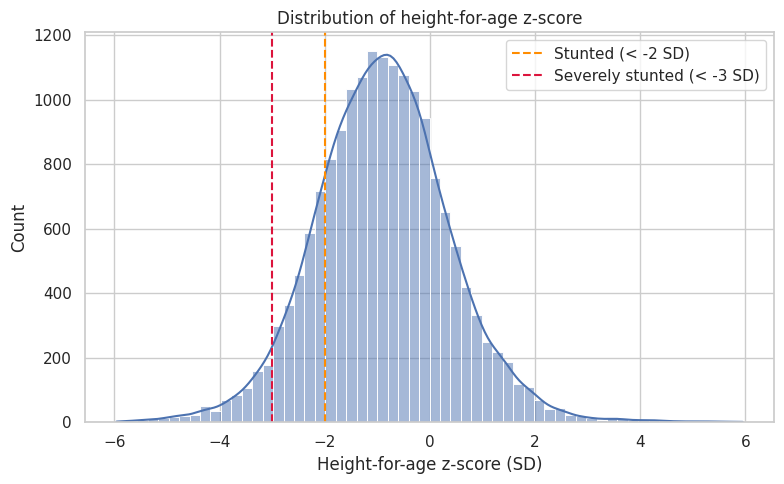

Valid HAZ measurements: 17,327 / 19,530 (88.7%)
Stunted (< -2 SD):          3,122  (16.0%)
Severely stunted (< -3 SD): 751  (3.8%)


In [ ]:

haz = df["height-for-age z-score"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(haz.dropna(), bins=60, kde=True, ax=ax, color="#4C72B0")
ax.axvline(-2, color="darkorange", linestyle="--", label="Stunted (< -2 SD)")
ax.axvline(-3, color="crimson", linestyle="--", label="Severely stunted (< -3 SD)")
ax.set_xlabel("Height-for-age z-score (SD)")
ax.set_title("Distribution of height-for-age z-score")
ax.legend()
plt.tight_layout()
plt.show()

n_valid = haz.notna().sum()
print(f"Valid HAZ measurements: {n_valid:,} / {len(haz):,} ({100 * n_valid / len(haz):.1f}%)")
print(f"Stunted (< -2 SD):          {(haz < -2).sum():,}  ({100 * (haz < -2).mean():.1f}%)")
print(f"Severely stunted (< -3 SD): {(haz < -3).sum():,}  ({100 * (haz < -3).mean():.1f}%)")



## 2.2 HAZ severity categories

Rather than working with the raw score, `stunting category` (built in
Part 1 §13) buckets it into three severity labels used throughout the
rest of this notebook:

| Category | HAZ range |
|---|---|
| **Severe stunting** | below -3 |
| **Moderate stunting** | -3 to -2 |
| **Normal growth** | -2 to 6 |


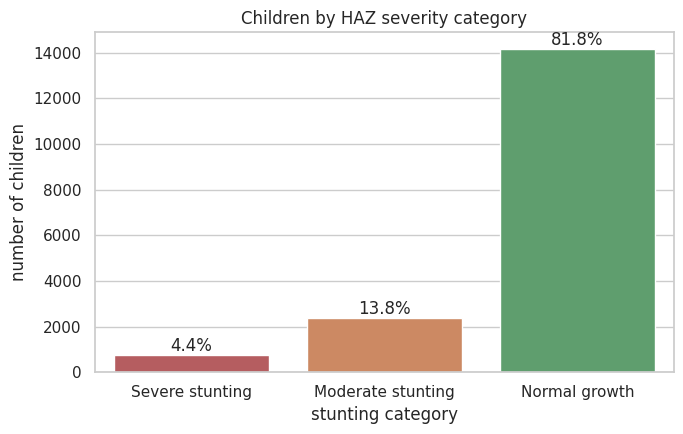

,count,pct_of_valid
stunting category,,
Severe stunting,761,4.4
Moderate stunting,2390,13.8
Normal growth,14176,81.8


In [ ]:

HAZ_CATEGORY_LABELS = ["Severe stunting", "Moderate stunting", "Normal growth"]

category_counts = df["stunting category"].value_counts().reindex(HAZ_CATEGORY_LABELS)
category_pct = (df["stunting category"].value_counts(normalize=True) * 100).reindex(HAZ_CATEGORY_LABELS)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index,
            order=HAZ_CATEGORY_LABELS, ax=ax, palette=["#C44E52", "#DD8452", "#55A868"], legend=False)
ax.set_ylabel("number of children")
ax.set_title("Children by HAZ severity category")
for i, (count, pct) in enumerate(zip(category_counts, category_pct)):
    ax.text(i, count, f"{pct:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

pd.DataFrame({"count": category_counts, "pct_of_valid": category_pct.round(1)})



## 2.3 Missingness across the feature set

Survey-based predictors (antenatal care, breastfeeding, birth weight) are
often only collected for a subset of children, so uneven missingness here
is expected. This chart shows which columns will need the most attention
in Part 3.


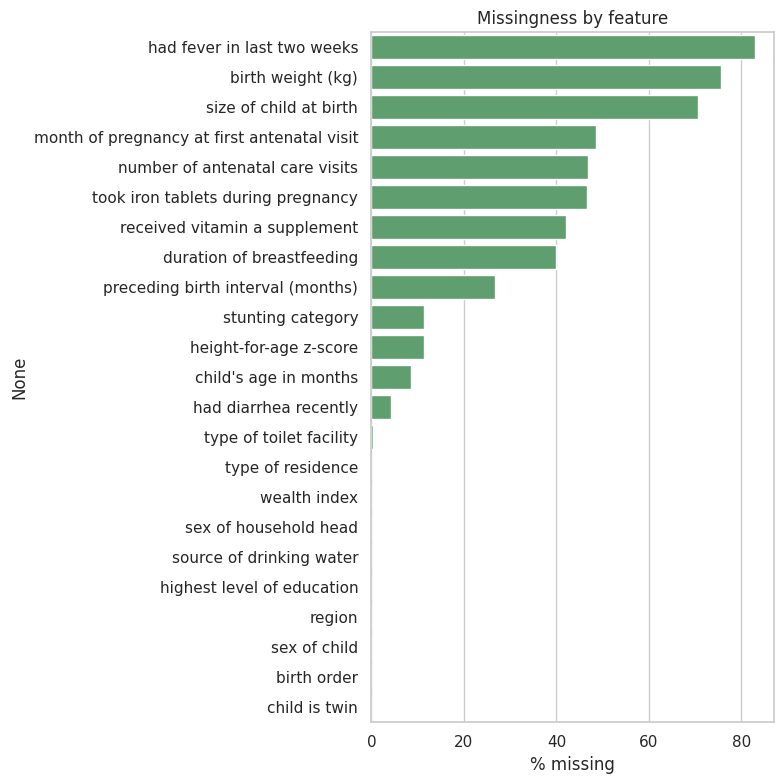

In [ ]:

feature_cols = [c for c in df.columns if c not in ("child id", "case id")]

missing_pct = (df[feature_cols].isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="#55A868")
ax.set_xlabel("% missing")
ax.set_title("Missingness by feature")
plt.tight_layout()
plt.show()

missing_pct.to_frame("pct_missing").to_csv(OUT_DIR / "eda_missingness_by_feature.csv")


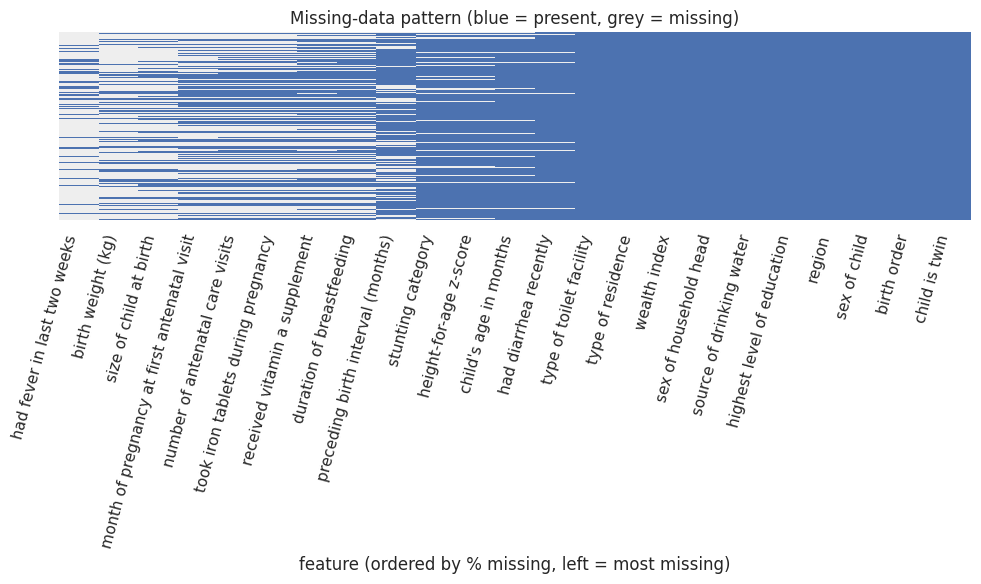

In [ ]:

# A heatmap shows both how much is missing (the bar chart above) and where
# it's missing (whether it clusters in the same rows/children) in one view.
# Columns are ordered by missingness rate so the pattern reads left-to-right.
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df[missing_pct.index].isnull(), cbar=False, yticklabels=False,
            cmap=ListedColormap(["#4C72B0", "#EEEEEE"]), ax=ax)
ax.set_title("Missing-data pattern (blue = present, grey = missing)")
ax.set_xlabel("feature (ordered by % missing, left = most missing)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()



## 2.4 Summary statistics for continuous predictors


In [ ]:

continuous_vars = ["child's age in months", "birth order", "preceding birth interval (months)",
                    "birth weight (kg)", "month of pregnancy at first antenatal visit",
                    "number of antenatal care visits", "height-for-age z-score"]
continuous_vars = [c for c in continuous_vars if c in df.columns]

summary_stats = df[continuous_vars].describe().T
summary_stats.to_csv(OUT_DIR / "eda_summary_stats.csv")
summary_stats


,count,mean,std,min,25%,50%,75%,max
child's age in months,17847.0,28.441923,17.365270,0.00,13.000,28.0,43.00,59.00
birth order,19530.0,3.210958,2.237028,1.00,1.000,3.0,4.00,15.00
preceding birth interval (months),14305.0,46.689269,31.691004,8.00,25.000,37.0,59.00,309.00
birth weight (kg),4755.0,3.180760,0.622111,0.60,2.900,3.2,3.50,6.00
month of pregnancy at first antenatal visit,10027.0,4.440610,1.629673,1.00,3.000,4.0,6.00,10.00
number of antenatal care visits,10401.0,4.064898,1.816728,0.00,3.000,4.0,5.00,20.00
height-for-age z-score,17327.0,-0.894771,1.282488,-5.96,-1.725,-0.9,-0.11,5.95



## 2.5 Categorical / ordinal predictor distributions


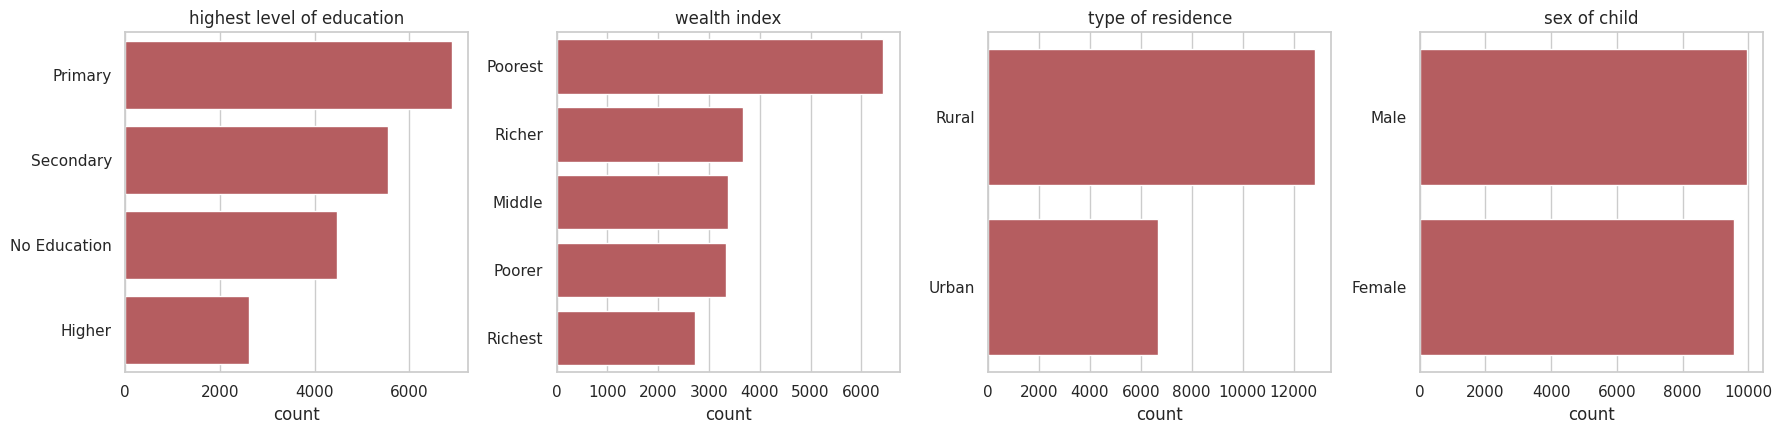

In [ ]:

cat_vars_to_plot = ["highest level of education", "wealth index", "type of residence", "sex of child"]
cat_vars_to_plot = [c for c in cat_vars_to_plot if c in df.columns]

fig, axes = plt.subplots(1, len(cat_vars_to_plot), figsize=(4.5 * len(cat_vars_to_plot), 4.5))
for ax, col in zip(axes, cat_vars_to_plot):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#C44E52")
    ax.set_title(col)
    ax.set_ylabel("")
    ax.set_xlabel("count")
plt.tight_layout()
plt.show()



## 2.6 Target vs. key categorical predictors

Boxplots of HAZ across wealth quintile, mother's education, and
urban/rural residence — three of the strongest documented predictors of
stunting — to confirm the expected direction of each relationship before
they go into a model.


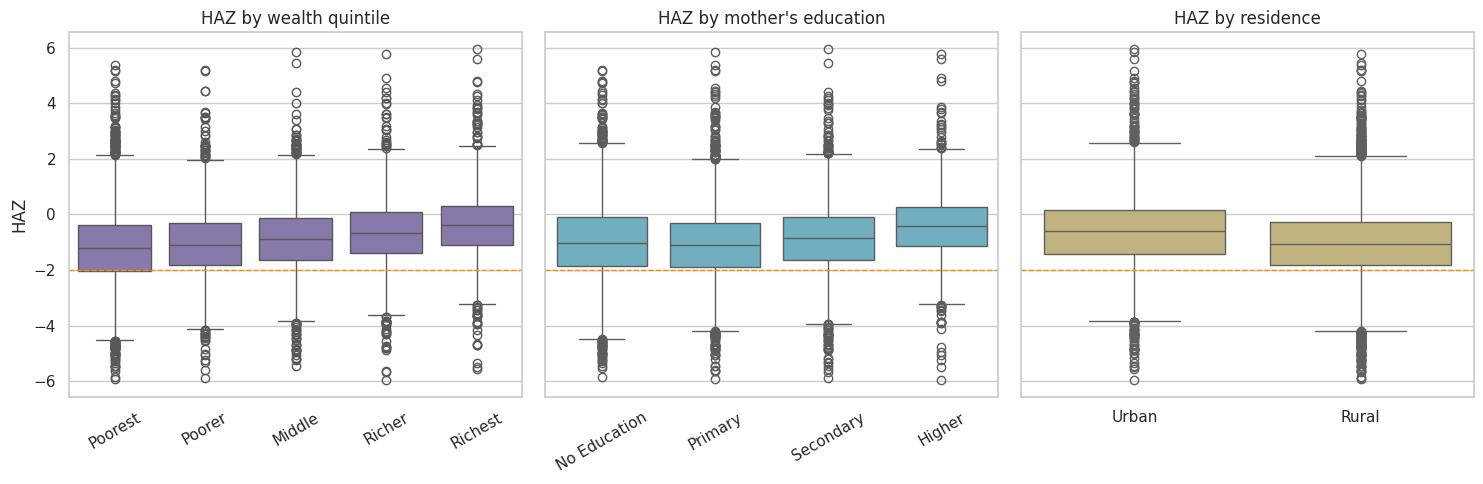

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

wealth_order = ["Poorest", "Poorer", "Middle", "Richer", "Richest"]
sns.boxplot(data=df, x="wealth index", y="height-for-age z-score", order=wealth_order, ax=axes[0], color="#8172B2")
axes[0].set_title("HAZ by wealth quintile")
axes[0].tick_params(axis="x", rotation=30)

edu_order = ["No Education", "Primary", "Secondary", "Higher"]
sns.boxplot(data=df, x="highest level of education", y="height-for-age z-score", order=edu_order, ax=axes[1], color="#64B5CD")
axes[1].set_title("HAZ by mother's education")
axes[1].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="type of residence", y="height-for-age z-score", ax=axes[2], color="#CCB974")
axes[2].set_title("HAZ by residence")

for ax in axes:
    ax.axhline(-2, color="darkorange", linestyle="--", linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel("HAZ")

plt.tight_layout()
plt.show()



## 2.7 Correlation among numeric predictors and the target

Limited, at this stage, to variables that are naturally numeric.
Categorical predictors like region, education, or wealth quintile aren't
meaningfully correlatable in text form — they get encoded in Part 3/4
instead.


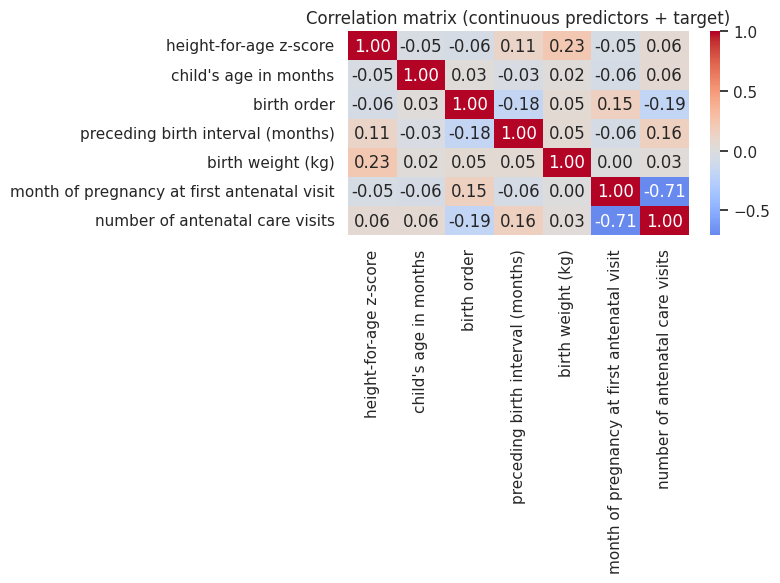

,corr_with_HAZ
birth weight (kg),0.225458
preceding birth interval (months),0.112515
number of antenatal care visits,0.061449
birth order,-0.055688
month of pregnancy at first antenatal visit,-0.053366
child's age in months,-0.047102


In [ ]:

corr_vars = ["height-for-age z-score", "child's age in months", "birth order",
             "preceding birth interval (months)", "birth weight (kg)",
             "month of pregnancy at first antenatal visit", "number of antenatal care visits"]
corr_vars = [c for c in corr_vars if c in df.columns]

corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation matrix (continuous predictors + target)")
plt.tight_layout()
plt.show()

corr["height-for-age z-score"].drop("height-for-age z-score").sort_values(key=abs, ascending=False).to_frame("corr_with_HAZ")



## 2.8 Geographic pattern: stunting by region

Stunting is well documented to vary sharply by county in Kenya (driven by
food security, health-system access, and water/sanitation infrastructure,
which themselves vary geographically). This is also the view we come back
to in Part 7's disaggregated evaluation, to check whether the model's
accuracy holds up evenly across regions or drops in specific counties.


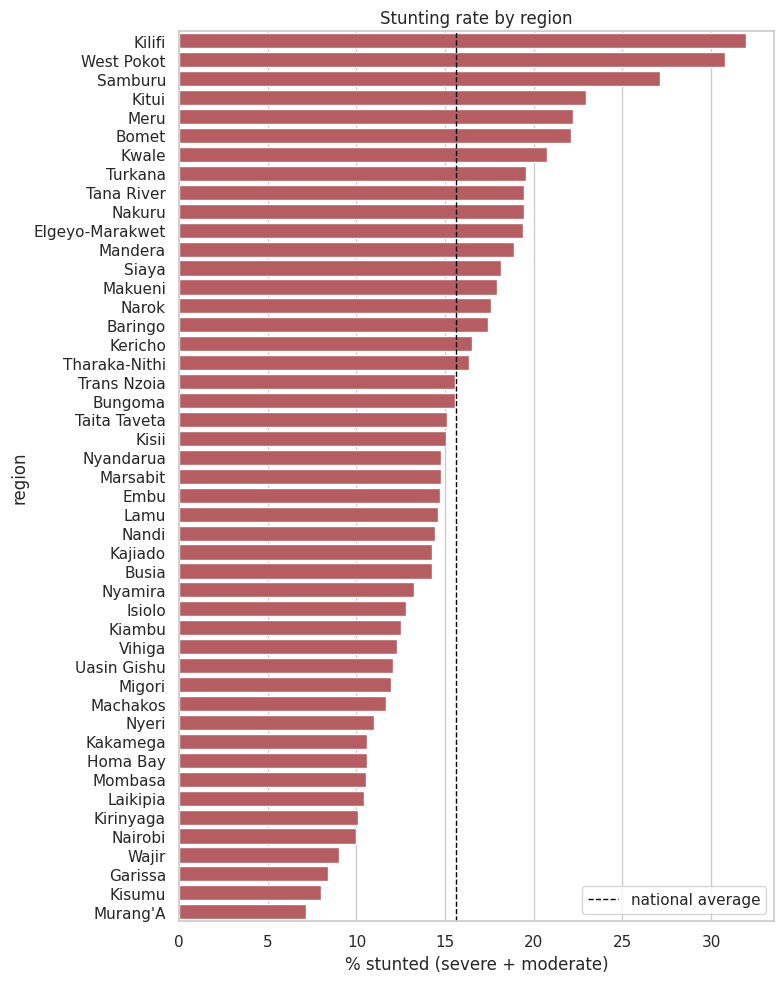

In [ ]:

region_stunting = (
    df.assign(is_stunted=df["stunting category"].isin(["Severe stunting", "Moderate stunting"]))
      .groupby("region")["is_stunted"].mean()
      .sort_values(ascending=False) * 100
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=region_stunting.values, y=region_stunting.index, ax=ax, color="#C44E52")
ax.axvline(region_stunting.mean(), color="black", linestyle="--", linewidth=1, label="national average")
ax.set_xlabel("% stunted (severe + moderate)")
ax.set_title("Stunting rate by region")
ax.legend()
plt.tight_layout()
plt.show()



# Part 3: Feature Engineering

This part turns the cleaned raw variables into a model-ready feature table:
fixing a couple of placeholder codes the general-purpose cleaning in Part 1
was too conservative to touch, deriving clinically meaningful features
(BMI, low birth weight, birth spacing, breastfeeding status...), and
encoding categorical predictors. Every derived feature is documented with
the formula/rule used to build it.

Like Part 2, this reloads from disk so it can be run on its own.


In [ ]:

df = pd.read_csv(OUT_DIR / "child_recode_clean.csv")
fe_log = []  # (feature, source_column(s), rule) — written out at the end for documentation

def log_feature(name, source, rule):
    fe_log.append({"feature": name, "source_columns": source, "rule": rule})



## 3.1 Close a gap the general-purpose cleaning missed

Part 1's missing-code recoding (step 6) matched codes whose value label
contained a phrase like "refused" or "not present" — a deliberately
conservative rule so it wouldn't guess. It looked at `v437`/`v438`
(mother's weight/height) and correctly cleared codes `9994` ("not present")
and `9995` ("refused"), but code `9996` ("other") doesn't match any of
those phrases and slipped through. For a body measurement, "other" is not
a numeric answer either, so we clear it here before using these columns to
build the maternal BMI feature.


In [ ]:

for col in ["v437", "v438"]:
    n_other = (df[col] == 9996).sum()
    df.loc[df[col] == 9996, col] = np.nan
    print(f"{col}: cleared {n_other} residual 'other' placeholder codes")


v437: cleared 12 residual 'other' placeholder codes
v438: cleared 12 residual 'other' placeholder codes



## 3.2 Anthropometric / birth-history features


In [ ]:

# --- Birth weight -----------------------------------------------------
# m19 is stored in kilograms * 1000 (3 implied decimals).
df["birthweight_kg"] = df["m19"] / 1000
df["low_birthweight"] = (df["birthweight_kg"] < 2.5).astype("Int8")
log_feature("birthweight_kg", "m19", "m19 / 1000 (stored *1000)")
log_feature("low_birthweight", "birthweight_kg", "1 if birthweight_kg < 2.5 kg (WHO low-birth-weight cutoff), else 0")

# --- Maternal BMI -------------------------------------------------------
# v437 (weight) and v438 (height) are stored *10 (1 implied decimal).
mother_weight_kg = df["v437"] / 10
mother_height_m = (df["v438"] / 10) / 100
df["mother_bmi"] = mother_weight_kg / (mother_height_m ** 2)
df["mother_thin"] = (df["mother_bmi"] < 18.5).astype("Int8")
df["mother_short_stature"] = (mother_height_m * 100 < 145).astype("Int8")
log_feature("mother_bmi", "v437, v438", "weight_kg / height_m^2, both /10 to undo DHS's *10 storage")
log_feature("mother_thin", "mother_bmi", "1 if BMI < 18.5 (WHO underweight cutoff), else 0")
log_feature("mother_short_stature", "v438", "1 if height < 145 cm (commonly used maternal short-stature cutoff), else 0")

df[["birthweight_kg", "low_birthweight", "mother_bmi", "mother_thin", "mother_short_stature"]].describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
birthweight_kg,4755.0,3.18076,0.622111,0.6,2.9,3.2,3.5,6.0
low_birthweight,19530.0,0.021966,0.146577,0.0,0.0,0.0,0.0,1.0
mother_bmi,10173.0,23.605726,5.246463,13.372749,19.852641,22.578489,26.372401,63.038474
mother_thin,19530.0,0.072453,0.259243,0.0,0.0,0.0,0.0,1.0
mother_short_stature,19530.0,0.002407,0.048999,0.0,0.0,0.0,0.0,1.0



## 3.3 Birth order and spacing features


In [ ]:

# b11 (preceding birth interval, months) is NaN for first-born children,
# which is structural (there is no preceding birth), not a data problem.
df["short_birth_interval"] = np.where(df["b11"].isna(), np.nan, (df["b11"] < 24).astype(float))
df["high_birth_order"] = (df["bord"] >= 4).astype("Int8")
df["is_twin_or_multiple"] = (df["b0"] > 0).astype("Int8")

log_feature("short_birth_interval", "b11", "1 if preceding birth interval < 24 months (WHO spacing guidance), NaN for first births")
log_feature("high_birth_order", "bord", "1 if this is the 4th or later live birth, else 0")
log_feature("is_twin_or_multiple", "b0", "1 if child is part of a multiple birth (b0 > 0), else 0")

df[["short_birth_interval", "high_birth_order", "is_twin_or_multiple"]].mean()


short_birth_interval    0.209647
high_birth_order        0.350691
is_twin_or_multiple     0.031951
dtype: Float64


## 3.4 Antenatal care and supplementation features


In [ ]:

df["anc_adequate"] = (df["m14"] >= 4).astype("Int8")           # WHO's older "4+ visits" benchmark
df["anc_early_start"] = (df["m13"] <= 3).astype("Int8")        # first antenatal visit in the 1st trimester
df["iron_supplemented"] = df["m45"].astype("Int8")             # already a clean 0/1
df["vitamin_a_received"] = df["h33"].isin([1, 2, 3]).astype("Int8")  # any documented/recalled receipt

log_feature("anc_adequate", "m14", "1 if 4+ antenatal visits reported, else 0")
log_feature("anc_early_start", "m13", "1 if first antenatal visit was in month 1-3, else 0")
log_feature("iron_supplemented", "m45", "carried over as-is (already 0/1)")
log_feature("vitamin_a_received", "h33", "1 if any Vitamin A receipt documented (card date, card mark, or mother-reported), else 0")

df[["anc_adequate", "anc_early_start", "iron_supplemented", "vitamin_a_received"]].mean()


anc_adequate          0.332207
anc_early_start       0.142448
iron_supplemented     0.896704
vitamin_a_received    0.375832
dtype: Float64


## 3.5 Breastfeeding features

`m4`/`m5` mix real durations with DHS status codes (`93` ever-but-not-
currently, `94` never breastfed, `95` still breastfeeding). We split that
into a clean categorical status and a numeric duration that's only
populated when a real duration exists.


In [ ]:

BF_STATUS_MAP = {93: "stopped", 94: "never", 95: "still_breastfeeding"}

df["breastfeeding_status"] = df["m4"].map(BF_STATUS_MAP)
df.loc[df["breastfeeding_status"].isna() & df["m4"].notna(), "breastfeeding_status"] = "stopped"  # any leftover numeric m4 duration

# m5 holds the numeric duration in months for resolvable cases; special
# codes 93/94 that survived Part 1's cleaning aren't real durations.
df["breastfeeding_duration_months"] = df["m5"].where(~df["m5"].isin([93, 94]))

log_feature("breastfeeding_status", "m4", "categorical: never / stopped / still_breastfeeding, decoded from DHS status codes 93-95")
log_feature("breastfeeding_duration_months", "m5", "m5 kept as-is except codes 93/94 (non-numeric statuses) set to NaN")

df[["breastfeeding_status", "breastfeeding_duration_months"]].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
breastfeeding_status,11728,3,still_breastfeeding,6788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
breastfeeding_duration_months,6788.0,NaN,NaN,NaN,10.815999,7.487932,0.0,5.0,10.0,16.0,35.0



## 3.6 Birth size feature


In [ ]:

# m18 is already a clean 1 (very large) .. 5 (very small) ordinal scale; add a simple binary flag on top.
df["small_at_birth"] = df["m18"].isin([4, 5]).astype("Int8")
log_feature("small_at_birth", "m18", "1 if size at birth reported as 'smaller than average' or 'very small', else 0")
df["small_at_birth"].mean()


np.float64(0.03922171018945213)


## 3.7 Water and sanitation (WASH) features

`v113` and `v116` use dozens of specific source/facility codes. We collapse
them to the standard JMP-style **improved / unimproved** classification
used in WHO/UNICEF water and sanitation reporting, which is far more
useful to a model than 15-30 sparse categories.

> Assumption: bottled water and "flush, don't know where" are counted as
> improved, following common JMP practice; results can be revisited if a
> stricter definition is preferred.


In [ ]:

IMPROVED_WATER_CODES = {10, 11, 12, 13, 14, 20, 21, 31, 41, 51, 71}     # piped, borehole, protected well/spring, rainwater, bottled
IMPROVED_SANITATION_CODES = {11, 12, 13, 15, 21, 22, 41}                # flush variants, VIP, slab pit latrine, composting

df["improved_water_source"] = df["v113"].isin(IMPROVED_WATER_CODES).astype("Int8")
df.loc[df["v113"].isna(), "improved_water_source"] = np.nan

df["improved_sanitation"] = df["v116"].isin(IMPROVED_SANITATION_CODES).astype("Int8")
df.loc[df["v116"].isna(), "improved_sanitation"] = np.nan

df["is_urban"] = (df["v025"] == 1).astype("Int8")

log_feature("improved_water_source", "v113", "1 if water source is JMP-'improved' (piped/borehole/protected well or spring/rainwater/bottled), else 0")
log_feature("improved_sanitation", "v116", "1 if toilet facility is JMP-'improved' (flush variants/VIP/slab pit latrine/composting), else 0")
log_feature("is_urban", "v025", "1 if residence is urban, 0 if rural")

df[["improved_water_source", "improved_sanitation", "is_urban"]].mean()


improved_water_source    0.660573
improved_sanitation      0.580027
is_urban                 0.342345
dtype: Float64


## 3.8 Encode remaining categorical predictors

- **Ordinal** variables (education, wealth) are kept as their existing
  numeric codes — the order is already meaningful, so one-hot encoding
  would throw information away.
- **Binary** variables are recoded to a clean, self-explanatory 0/1.
- **Nominal** variables with more than two unlabeled categories (region)
  are one-hot encoded, since there's no natural ordering to preserve.


In [ ]:

# Binary recodes -> clean, self-documenting 0/1
df["is_female"] = (df["b4"] == 2).astype("Int8")
df["female_headed_household"] = (df["v151"] == 2).astype("Int8")
# h11 (diarrhea) is already 0/1 in this file; included here for completeness
df["had_diarrhea_recently"] = df["h11"].astype("Int8")

log_feature("is_female", "b4", "1 if female, 0 if male")
log_feature("female_headed_household", "v151", "1 if household head is female, 0 if male")
log_feature("had_diarrhea_recently", "h11", "carried over as-is (already 0/1)")

# One-hot encode region (nominal, 47 counties) - prefix keeps columns identifiable
region_dummies = pd.get_dummies(df["v024"], prefix="region", dtype="Int8")
df = pd.concat([df, region_dummies], axis=1)
log_feature(f"region_* ({region_dummies.shape[1]} columns)", "v024", "one-hot encoded county of residence")

print(f"Added {region_dummies.shape[1]} one-hot region columns.")


Added 47 one-hot region columns.



## 3.9 HAZ severity category label

Alongside the continuous `hw70` z-score, we add the three-level severity
label introduced in Part 2's EDA (`Severe stunting` / `Moderate stunting`
/ `Normal growth`), so it's available directly from the saved table rather
than needing to be recomputed downstream.


In [ ]:

HAZ_CATEGORY_BINS = [-6.01, -3, -2, 6.01]
HAZ_CATEGORY_LABELS = ["Severe stunting", "Moderate stunting", "Normal growth"]

df["haz_category"] = pd.cut(df["hw70"] / 100, bins=HAZ_CATEGORY_BINS, labels=HAZ_CATEGORY_LABELS)
log_feature("haz_category", "hw70",
            "Severe stunting: HAZ < -3 | Moderate stunting: -3 <= HAZ < -2 | Normal growth: HAZ >= -2")

df["haz_category"].value_counts()


haz_category
Normal growth        14176
Moderate stunting     2390
Severe stunting        761
Name: count, dtype: int64


## 3.10 Assemble the final model-ready table

Raw columns that have now been superseded by an engineered version are
dropped so the final table isn't carrying two copies of the same
information (e.g. `m19` -> `birthweight_kg`). Identifier columns and the
target are always kept.


In [ ]:

target_col = "hw70"
id_cols = ["child_id", "caseid", "bidx"]

superseded_raw_cols = [
    "m19",            # -> birthweight_kg
    "v437", "v438",   # -> mother_bmi, mother_thin, mother_short_stature
    "m4", "m5",       # -> breastfeeding_status, breastfeeding_duration_months
    "b4", "v151", "h11",  # -> is_female, female_headed_household, had_diarrhea_recently
    "v024",           # -> region_* dummies
]
superseded_raw_cols = [c for c in superseded_raw_cols if c in df.columns]

# *_label helper columns were for human readability during EDA, not modeling inputs
label_cols = [c for c in df.columns if c.endswith("_label")]

drop_cols = superseded_raw_cols + label_cols
model_df = df.drop(columns=drop_cols)

print(f"Dropped {len(superseded_raw_cols)} raw columns superseded by engineered features: {superseded_raw_cols}")
print(f"Dropped {len(label_cols)} EDA-only *_label columns.")
print(f"Final model-ready table: {model_df.shape[0]:,} rows x {model_df.shape[1]:,} columns")
model_df.head(3)


Dropped 9 raw columns superseded by engineered features: ['m19', 'v437', 'v438', 'm4', 'm5', 'b4', 'v151', 'h11', 'v024']
Dropped 8 EDA-only *_label columns.
Final model-ready table: 19,530 rows x 90 columns


,child_id,caseid,bidx,hw70,hw1,bord,b0,b11,m18,m19a,v106,v133,m14,m13,m45,v190,v113,v116,v025,h33,h10,birthweight_kg,low_birthweight,mother_bmi,mother_thin,mother_short_stature,short_birth_interval,high_birth_order,is_twin_or_multiple,anc_adequate,...,region_19,region_20,region_21,region_22,region_23,region_24,region_25,region_26,region_27,region_28,region_29,region_30,region_31,region_32,region_33,region_34,region_35,region_36,region_37,region_38,region_39,region_40,region_41,region_42,region_43,region_44,region_45,region_46,region_47,haz_category
0,1 4 2_1,1 4 2,1,362.0,8.0,4,0,92.0,2.0,2.0,0,0,5.0,5.0,1.0,4,14,22.0,1,0.0,NaN,4.0,0,37.351305,0,0,0.0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Normal growth
1,1 13 2_1,1 13 2,1,-11.0,36.0,5,0,30.0,NaN,NaN,2,12,NaN,NaN,NaN,5,12,12.0,1,NaN,NaN,NaN,0,39.511578,0,0,0.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Normal growth
2,1 26 2_1,1 26 2,1,-86.0,58.0,3,0,23.0,NaN,NaN,2,12,NaN,NaN,NaN,4,13,21.0,1,NaN,NaN,NaN,0,29.648743,0,0,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Normal growth



## 3.11 Save the feature-engineered dataset

Missing values in the engineered features are left as `NaN` rather than
imputed here — imputation strategy (median, model-based, etc.) is a
modeling-stage decision that depends on the algorithm being used, so it's
kept out of scope for this notebook. The feature engineering log records
exactly how each new column was derived.


In [ ]:

model_csv = OUT_DIR / "child_recode_model_ready.csv"
model_df.to_csv(model_csv, index=False)

fe_log_df = pd.DataFrame(fe_log)
fe_log_df.to_csv(OUT_DIR / "feature_engineering_log.csv", index=False)

print("Saved:")
print(f"  {model_csv}  ({model_df.shape[0]:,} rows x {model_df.shape[1]:,} columns)")
print(f"  {OUT_DIR / 'feature_engineering_log.csv'}  ({len(fe_log_df)} engineered features documented)")
fe_log_df


Saved:
  cleaned_output/child_recode_model_ready.csv  (19,530 rows x 90 columns)
  cleaned_output/feature_engineering_log.csv  (23 engineered features documented)


,feature,source_columns,rule
0,birthweight_kg,m19,m19 / 1000 (stored *1000)
1,low_birthweight,birthweight_kg,1 if birthweight_kg < 2.5 kg (WHO low-birth-we...
2,mother_bmi,"v437, v438","weight_kg / height_m^2, both /10 to undo DHS's..."
3,mother_thin,mother_bmi,"1 if BMI < 18.5 (WHO underweight cutoff), else 0"
4,mother_short_stature,v438,1 if height < 145 cm (commonly used maternal s...
5,short_birth_interval,b11,1 if preceding birth interval < 24 months (WHO...
6,high_birth_order,bord,"1 if this is the 4th or later live birth, else 0"
7,is_twin_or_multiple,b0,1 if child is part of a multiple birth (b0 > 0...
8,anc_adequate,m14,"1 if 4+ antenatal visits reported, else 0"
9,anc_early_start,m13,"1 if first antenatal visit was in month 1-3, e..."



# Part 4: Feature Extraction and Representation

Parts 1-3 produced a clean, engineered table, but it isn't quite ready for
`scikit-learn` yet: the target is still a continuous z-score, one feature
(`breastfeeding_status`) is still text, and every feature still has
`NaN`s. This part turns `child_recode_model_ready.csv` into a numeric
matrix a classifier can consume.

**Framing the problem as classification.** The rest of this notebook
predicts the **HAZ severity category** introduced in Part 2/3
(`Severe stunting` / `Moderate stunting` / `Normal growth`) rather than the
continuous z-score, since "classification using supervised learning" and
the evaluation metrics that follow (precision/recall/ROC-AUC) are built
for a categorical target.


In [ ]:

model_df = pd.read_csv(OUT_DIR / "child_recode_model_ready.csv")

# --- 4.1 Classification target ---------------------------------------
# haz_category was already derived in Part 3 (Severe stunting: HAZ < -3,
# Moderate stunting: -3 <= HAZ < -2, Normal growth: HAZ >= -2).

# A child with no valid anthropometry has no label at all - these rows
# can't be used for supervised learning and are dropped here (not earlier,
# since Parts 1-3 are about the data generally, not this specific task).
before_n = len(model_df)
model_df = model_df[model_df["haz_category"].notna()].reset_index(drop=True)
print(f"Dropped {before_n - len(model_df):,} rows with missing HAZ (no label). "
      f"{len(model_df):,} rows remain.")

print(model_df["haz_category"].value_counts(normalize=True).rename("share"))


Dropped 2,203 rows with missing HAZ (no label). 17,327 rows remain.
haz_category
Normal growth        0.818145
Moderate stunting    0.137935
Severe stunting      0.043920
Name: share, dtype: float64



## 4.2 Separate identifiers, target, and features

`hw70` (the raw z-score the label was derived from) is dropped from the
feature set — keeping it would let the model "cheat" by learning the exact
threshold rather than the underlying risk factors.


In [ ]:

id_cols = ["child_id", "caseid", "bidx"]
target_col = "haz_category"
leakage_cols = ["hw70"]  # source of the label - must not be used as a feature

feature_cols = [c for c in model_df.columns if c not in id_cols + [target_col] + leakage_cols]

X = model_df[feature_cols].copy()
y = model_df[target_col].astype(str).copy()  # plain strings avoid categorical-dtype quirks in sklearn

categorical_features = ["breastfeeding_status"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]:,} columns "
      f"({len(numeric_features)} numeric, {len(categorical_features)} categorical)")


Feature matrix: 17,327 rows x 85 columns (84 numeric, 1 categorical)



## 4.3 Train/test split

Split before any imputation or scaling is fitted, so nothing about the
test set leaks into how those transformations are learned. Stratified on
the target since the three categories are quite imbalanced (roughly
73% / 12% / 4% normal/moderate/severe of valid measurements) — a plain
random split could otherwise shift that balance between splits.


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class shares:")
print(y_train.value_counts(normalize=True))
print("\nTest class shares:")
print(y_test.value_counts(normalize=True))


Train class shares:
haz_category
Normal growth        0.818123
Moderate stunting    0.137941
Severe stunting      0.043936
Name: proportion, dtype: float64

Test class shares:
haz_category
Normal growth        0.818234
Moderate stunting    0.137911
Severe stunting      0.043855
Name: proportion, dtype: float64



## 4.4 Build the preprocessing pipeline

A single `ColumnTransformer`, fit only on the training data, handles the
remaining representation work:

- **Numeric features:** median imputation (robust to the outliers already
  seen in Part 2), then standardization — required for logistic regression,
  harmless for the tree-based models used later.
- **Categorical feature (`breastfeeding_status`):** missing values become
  their own explicit `"missing"` category (a child's mother not answering
  the breastfeeding question is itself informative), then one-hot encoding.

Wrapping this in a `Pipeline`/`ColumnTransformer` means every model below
gets an identical, leakage-safe representation, and the same object can
transform new data at prediction time.


In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# Fit on train, inspect the resulting representation size
X_train_transformed = preprocessor.fit_transform(X_train)
print(f"Encoded feature matrix: {X_train_transformed.shape[1]} columns "
      f"(from {X.shape[1]} original features, after one-hot expansion)")


Encoded feature matrix: 88 columns (from 85 original features, after one-hot expansion)



# Part 5: Model Training and Evaluation

With `preprocessor` handling representation, each model below is wrapped
in its own `Pipeline` (`preprocessor` -> classifier), fit on the training
split, and scored with 5-fold stratified cross-validation on the training
data — giving a variance-aware estimate of generalization performance
before anything touches the held-out test set.


In [ ]:

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Macro-averaged precision/recall/F1 weight all three classes equally regardless
# of size, which matters here since "severe stunting" is a small minority of
# cases; roc_auc_ovr scores each class one-vs-rest and averages the result.
scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_ovr"]

def cross_validate_model(name, pipeline):
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision_macro"].mean(),
        "recall": scores["test_recall_macro"].mean(),
        "f1": scores["test_f1_macro"].mean(),
        "roc_auc": scores["test_roc_auc_ovr"].mean(),
    }



## 5.1 The required baseline: majority-class prediction

Before training anything, the simplest possible "model" — always predict
the most common class, `Normal growth` — sets the floor every real model
must clear. If a trained classifier can't beat this, it hasn't learned
anything useful; a headline metric only means something in comparison to
this number.


In [ ]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, accuracy_score
from sklearn.preprocessing import label_binarize

baseline_clf = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_clf.fit(X_train, y_train)

baseline_pred = baseline_clf.predict(X_test)
baseline_proba = baseline_clf.predict_proba(X_test)  # identical row for every sample - no ranking signal

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    y_test, baseline_pred, average="macro", zero_division=0, labels=sorted(y_test.unique())
)
# predict_proba is constant across all rows, so there's no ranking information at
# all - roc_auc_score still computes cleanly and lands at ~0.5 (chance) per class.
baseline_roc_auc = roc_auc_score(
    label_binarize(y_test, classes=baseline_clf.classes_), baseline_proba,
    average="macro", multi_class="ovr"
)

print(f"Baseline: always predict the majority class ('{baseline_clf.classes_[baseline_clf.class_prior_.argmax()]}')")
print(f"  Accuracy:   {baseline_accuracy:.3f}")
print(f"  Macro F1:   {baseline_f1:.3f}")
print(f"  ROC-AUC:    {baseline_roc_auc:.3f}  (no ranking signal, as expected)")

cv_results = [{
    "model": "Baseline (majority class)",
    "accuracy": baseline_accuracy,
    "precision": baseline_precision,
    "recall": baseline_recall,
    "f1": baseline_f1,
    "roc_auc": baseline_roc_auc,
}]
pd.DataFrame(cv_results)


Baseline: always predict the majority class ('Normal growth')
  Accuracy:   0.818
  Macro F1:   0.300
  ROC-AUC:    0.500  (no ranking signal, as expected)


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority class),0.818234,0.272745,0.333333,0.300011,0.5



## 5.2 Cross-validated baseline: logistic regression

A linear model is a sensible first *learned* baseline: fast, interpretable
via its coefficients, and a useful floor that the more flexible models
below need to beat to justify their extra complexity. `class_weight="balanced"`
compensates for the class imbalance (normal growth is ~6x more common than
moderate stunting, and ~19x more common than severe stunting).


In [ ]:

from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

cv_results.append(cross_validate_model("Logistic Regression", logreg_pipeline))
pd.DataFrame(cv_results)


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (majority class),0.818234,0.272745,0.333333,0.300011,0.500000
1,Logistic Regression,0.554002,0.397633,0.465258,0.372274,0.670931



# Part 6: Classification Using Supervised Learning Techniques

Beyond the linear baseline, this section trains a broader spread of
supervised classifiers — a single decision tree (interpretable, but prone
to overfitting), and two tree **ensembles**, random forest (bagging) and
gradient boosting (boosting) — to see how much a more flexible decision
boundary helps on this feature set. All four share the exact same
preprocessing pipeline from Part 4, so results are directly comparable.


In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

candidate_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=None, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

pipelines = {"Logistic Regression": logreg_pipeline}  # keep the Part 5 baseline in the comparison
for name, clf in candidate_models.items():
    pipelines[name] = Pipeline(steps=[("preprocess", preprocessor), ("clf", clf)])
    cv_results.append(cross_validate_model(name, pipelines[name]))

cv_results_df = pd.DataFrame(cv_results).set_index("model")
cv_results_df.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline (majority class),0.818,0.273,0.333,0.300,0.500
Logistic Regression,0.554,0.398,0.465,0.372,0.671
Decision Tree,0.503,0.378,0.429,0.339,0.616
Random Forest,0.818,0.534,0.337,0.309,0.667
Gradient Boosting,0.817,0.480,0.342,0.321,0.701


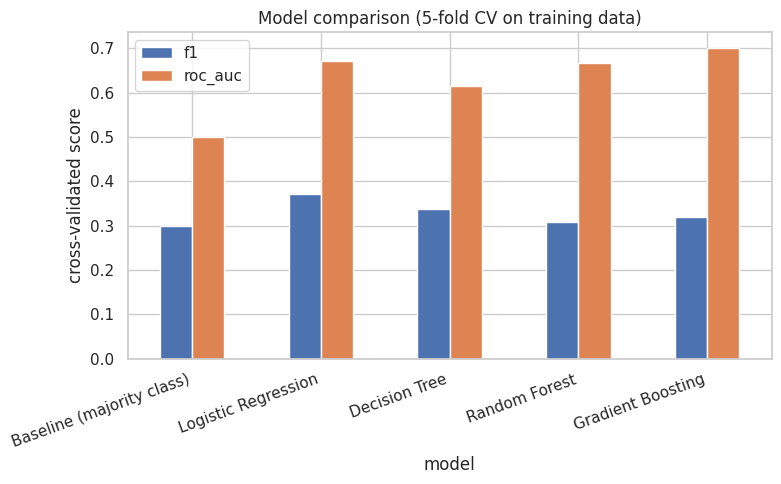

In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))
cv_results_df[["f1", "roc_auc"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("cross-validated score")
ax.set_title("Model comparison (5-fold CV on training data)")
ax.set_xticklabels(cv_results_df.index, rotation=20, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()



## 6.1 Fit the best-performing model and evaluate on the held-out test set

Cross-validation picks the strongest candidate; it's then refit on the
*entire* training split and scored once on the test set — the first time
the test data is touched — for an unbiased read on generalization.


In [ ]:

best_model_name = cv_results_df["roc_auc"].idxmax()
best_pipeline = pipelines[best_model_name]
print(f"Best model by cross-validated ROC-AUC: {best_model_name}")

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)  # shape (n_samples, n_classes)


Best model by cross-validated ROC-AUC: Gradient Boosting



## 6.2 Hyperparameter tuning decision

`best_pipeline` above was fit with the same fixed hyperparameters every
candidate used in Part 6's comparison (e.g. `RandomForestClassifier(
n_estimators=100, max_depth=None)`, `GradientBoostingClassifier()` at
sklearn's defaults) — reasonable, well-calibrated starting points, not a
tuned configuration. Tuning is capped at one manual round here rather than
an exhaustive search: a `GridSearchCV` over dozens of combinations would
burn far more compute than the question deserves, and the model most likely
to fix a real weakness in this data is a better *feature*, not a better
hyperparameter.

The rule applied: try one deliberate adjustment aimed at the tuned model's
specific tendency — for a random forest, that's reducing variance from
individual trees by widening the forest and giving trees more room to
specialize on the minority `Severe stunting` class — cross-validate it once,
and stop. If it doesn't beat the untuned version, keep the simpler,
untuned model rather than chasing a marginal gain.


In [ ]:

tuned_candidates = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=5, class_weight="balanced", random_state=42,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=2000, C=0.5, class_weight="balanced", random_state=42,
    ),
}

if best_model_name in tuned_candidates:
    tuned_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("clf", tuned_candidates[best_model_name])])
    tuned_result = cross_validate_model(f"{best_model_name} (tuned)", tuned_pipeline)
    untuned_result = next(r for r in cv_results if r["model"] == best_model_name)

    comparison = pd.DataFrame([untuned_result, tuned_result]).set_index("model")
    display(comparison.style.format("{:.3f}"))

    if tuned_result["roc_auc"] > untuned_result["roc_auc"]:
        print(f"Tuned variant improves ROC-AUC "
              f"({untuned_result['roc_auc']:.3f} -> {tuned_result['roc_auc']:.3f}); adopting it.")
        pipelines[best_model_name] = tuned_pipeline
        cv_results.append(tuned_result)
        cv_results_df = pd.DataFrame(cv_results).set_index("model")
    else:
        print(f"Tuned variant does not beat the untuned model "
              f"({tuned_result['roc_auc']:.3f} vs {untuned_result['roc_auc']:.3f} ROC-AUC); "
              "keeping the simpler, untuned version and stopping here rather than "
              "running a broader search.")
else:
    print(f"No manual tuning variant defined for {best_model_name}; keeping defaults.")



## 6.3 A regression view: predicting the continuous HAZ z-score

Everything above treats this as a **classification** problem — predicting
the bucket a child falls into (severe stunting / moderate stunting / normal
growth) — which is the correct framing for the target we actually care
about, since `haz_category` is categorical (three unordered-in-model, but
clinically ordered, labels), not a number. That's also why logistic
regression, decision tree, random forest, and gradient boosting are the
right model family here: they are classifiers, built to output class
probabilities, and the metrics used to judge them (macro-F1, ROC-AUC,
per-class precision/recall) are classification metrics.

For completeness, this section instead predicts `hw70`, the **continuous**
height-for-age z-score the categories were derived from. Predicting a real
number is a regression problem, so it calls for regression models — here a
**linear regression** baseline and a **random forest regressor** — scored
with regression metrics:

- **RMSE (root mean squared error):** the average prediction error, in the
  same units as the z-score itself, with larger errors penalized more
  heavily than small ones (because errors are squared before averaging).
  This is the headline number for this view — it tells us, on average, how
  many z-score units off a prediction is, while still coming down hard on
  the occasional bad miss.
- **R² (coefficient of determination):** the share of the variance in the
  z-score that the model explains, on a 0-1 scale (1 = perfect, 0 = no
  better than always predicting the mean). Useful for judging *how much*
  signal the predictors carry about HAZ overall, independent of the z-score's
  own units.
- **MAE (mean absolute error):** the average absolute size of the error,
  without squaring — so, unlike RMSE, every child's error counts equally
  regardless of how large it is. Comparing MAE to RMSE shows whether error
  is spread fairly evenly (the two stay close) or concentrated in a few
  large misses (RMSE noticeably higher than MAE).

Same train/test rows and the same leakage-safe `preprocessor` from Part 4
are reused here — only the target and the model family change.


In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate as cross_validate_reg
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Continuous target: the raw HAZ z-score that haz_category was derived from.
y_reg = model_df.loc[X.index, "hw70"]
y_reg_train = y_reg.loc[X_train.index]
y_reg_test = y_reg.loc[X_test.index]

regression_candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, max_depth=None, random_state=42, n_jobs=-1
    ),
}

reg_scoring = ["neg_root_mean_squared_error", "r2", "neg_mean_absolute_error"]
reg_cv_results = []
reg_pipelines = {}

for name, reg in regression_candidates.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("reg", reg)])
    reg_pipelines[name] = pipe
    scores = cross_validate_reg(pipe, X_train, y_reg_train, cv=5, scoring=reg_scoring, n_jobs=-1)
    reg_cv_results.append({
        "model": name,
        "rmse": -scores["test_neg_root_mean_squared_error"].mean(),
        "mae": -scores["test_neg_mean_absolute_error"].mean(),
        "r2": scores["test_r2"].mean(),
    })

reg_cv_df = pd.DataFrame(reg_cv_results).set_index("model")
reg_cv_df.style.format("{:.3f}")


In [ ]:

# Refit the stronger regressor (lowest cross-validated RMSE) on the full
# training split and score it once on the held-out test set.
best_reg_name = reg_cv_df["rmse"].idxmin()
best_reg_pipeline = reg_pipelines[best_reg_name]
print(f"Best regressor by cross-validated RMSE: {best_reg_name}")

best_reg_pipeline.fit(X_train, y_reg_train)
y_reg_pred = best_reg_pipeline.predict(X_test)

test_rmse = mean_squared_error(y_reg_test, y_reg_pred, squared=False)
test_mae = mean_absolute_error(y_reg_test, y_reg_pred)
test_r2 = r2_score(y_reg_test, y_reg_pred)

print(f"Held-out test set:")
print(f"  RMSE: {test_rmse:.3f} z-score units")
print(f"  MAE:  {test_mae:.3f} z-score units")
print(f"  R2:   {test_r2:.3f}")


In [ ]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.3, s=15, color="#4C72B0")
lims = [min(y_reg_test.min(), y_reg_pred.min()), max(y_reg_test.max(), y_reg_pred.max())]
ax.plot(lims, lims, color="#DD8452", linestyle="--", label="perfect prediction")
ax.axvline(-2, color="grey", linestyle=":", linewidth=1)
ax.axvline(-3, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Actual HAZ z-score")
ax.set_ylabel("Predicted HAZ z-score")
ax.set_title(f"{best_reg_name}: predicted vs. actual HAZ\n(dotted lines = WHO -2 / -3 SD thresholds)")
ax.legend()
plt.tight_layout()
plt.show()



**Reading this view:** the scatterplot's dotted lines mark the same -2 SD /
-3 SD WHO thresholds used to build `haz_category` — points that cross those
lines are where a regression error could flip a child's classification bucket
even though the numeric error looks small. This regression view is
diagnostic rather than the model we'd deploy: it tells us how precisely the
predictors track the underlying z-score, but the classification models above
remain primary, since a discrete severity label — not a raw z-score — is
what a health worker acts on.



# Part 7: Model Evaluation and Performance Analysis

A closer look at the best model's test-set performance: the full
precision/recall/F1 breakdown, the confusion matrix (where its errors
actually fall), the ROC curve, and — for the tree-based models — which
engineered features it relied on most, tying the result back to Part 3.


In [ ]:

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

CLASS_ORDER = HAZ_CATEGORY_LABELS  # ["Severe stunting", "Moderate stunting", "Normal growth"]

from sklearn.metrics import f1_score

test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
test_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro", labels=best_pipeline.classes_)

print(f"Test-set performance — {best_model_name}\n")
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER, zero_division=0))
print(f"Macro F1:  {test_f1:.3f}  (vs. majority-class baseline {baseline_f1:.3f}, "
      f"+{test_f1 - baseline_f1:.3f})")
print(f"ROC-AUC:   {test_auc:.3f}  (vs. majority-class baseline {baseline_roc_auc:.3f}, "
      f"+{test_auc - baseline_roc_auc:.3f})")


Test-set performance — Gradient Boosting

                   precision    recall  f1-score   support

  Severe stunting       0.25      0.02      0.04       152
Moderate stunting       0.32      0.02      0.03       478
    Normal growth       0.82      0.99      0.90      2836

         accuracy                           0.82      3466
        macro avg       0.46      0.34      0.32      3466
     weighted avg       0.73      0.82      0.74      3466



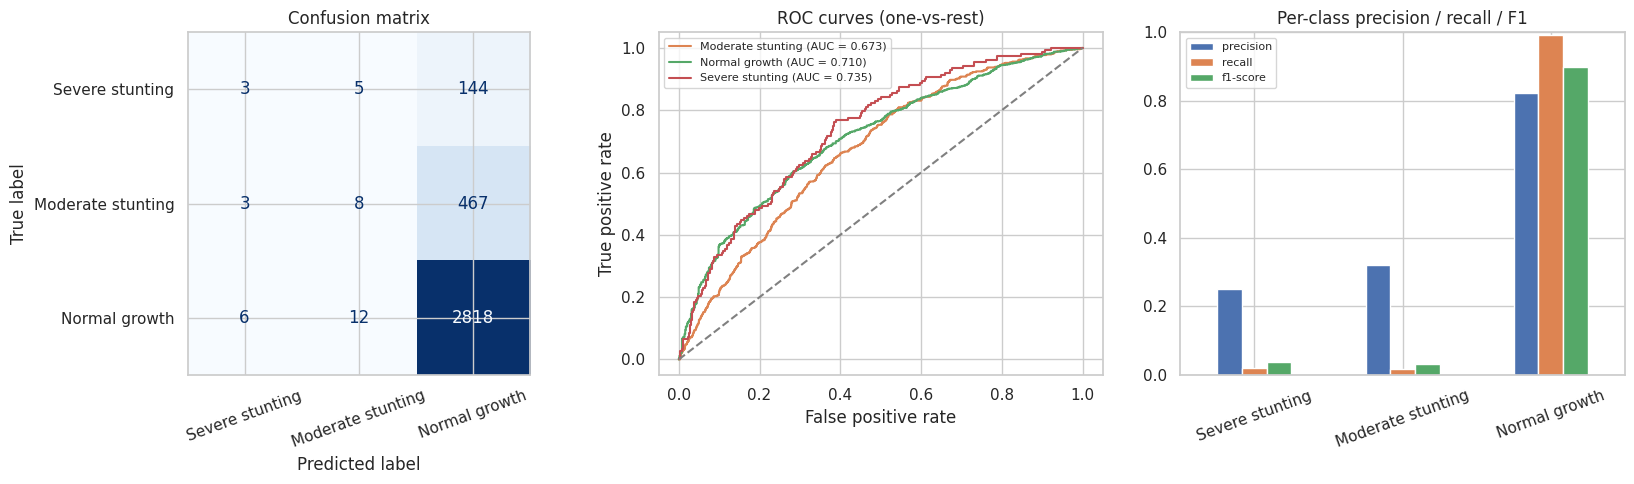

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Confusion matrix -----------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(ax=axes[0], colorbar=False, cmap="Blues", xticks_rotation=20)
axes[0].set_title("Confusion matrix")

# --- Per-class ROC curves (one-vs-rest) ------------------------------------
# best_pipeline.classes_ gives the column order of predict_proba's output -
# binarizing y_test against that same order keeps everything aligned.
model_classes = best_pipeline.classes_
y_test_bin = label_binarize(y_test, classes=model_classes)

colors = {"Severe stunting": "#C44E52", "Moderate stunting": "#DD8452", "Normal growth": "#55A868"}
for i, cls in enumerate(model_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    axes[1].plot(fpr, tpr, color=colors.get(cls, None), label=f"{cls} (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curves (one-vs-rest)")
axes[1].legend(fontsize=8)

# --- Per-class precision/recall/F1 ------------------------------------------
report_dict = classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.loc[CLASS_ORDER, ["precision", "recall", "f1-score"]]
report_df.plot(kind="bar", ax=axes[2], color=["#4C72B0", "#DD8452", "#55A868"])
axes[2].set_title("Per-class precision / recall / F1")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(fontsize=8)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.2f", fontsize=7, padding=1)

plt.tight_layout()
plt.show()



## 7.1 Feature importance

Which engineered features the best model actually leans on — useful both
as a sanity check (do the top features match the known stunting risk
factors from Part 2's EDA?) and as a guide for where future feature
engineering effort would pay off most.


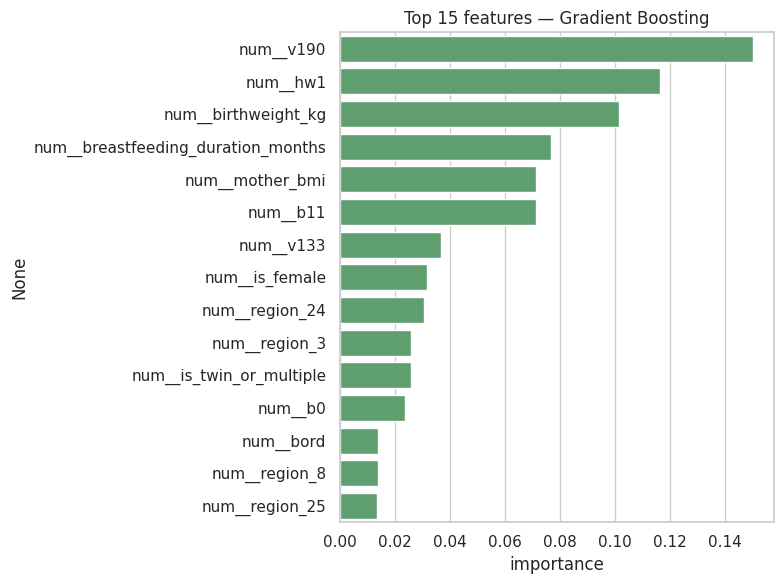

In [ ]:

fitted_clf = best_pipeline.named_steps["clf"]
feature_names = best_pipeline.named_steps["preprocess"].get_feature_names_out()

if hasattr(fitted_clf, "feature_importances_"):
    importances = pd.Series(fitted_clf.feature_importances_, index=feature_names)
elif hasattr(fitted_clf, "coef_"):
    # Multi-class logistic regression has one coefficient row per class;
    # averaging their magnitudes gives one overall importance per feature.
    coef = fitted_clf.coef_
    importances = pd.Series(np.abs(coef).mean(axis=0), index=feature_names)
else:
    importances = None

if importances is not None:
    top_importances = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x=top_importances.values, y=top_importances.index, ax=ax, color="#55A868")
    ax.set_title(f"Top 15 features — {best_model_name}")
    ax.set_xlabel("importance")
    ax.bar_label(ax.containers[0], fmt="%.3f", fontsize=8, padding=2)
    plt.tight_layout()
    plt.show()



## 7.2 Explore ensemble techniques to improve performance

Random forest and gradient boosting (Part 6) are already ensembles built
from many decision trees. This section goes a level further and combines
*different families* of model — logistic regression, random forest, and
gradient boosting — into a single **voting ensemble**, on the theory that
models which make different kinds of mistakes can partly correct for one
another. A **stacking ensemble** (a meta-model learned on top of the base
models' predictions) is included alongside it for comparison.


In [ ]:

from sklearn.ensemble import VotingClassifier, StackingClassifier

ensemble_estimators = [
    ("logreg", pipelines["Logistic Regression"]),
    ("rf", pipelines["Random Forest"]),
    ("gb", pipelines["Gradient Boosting"]),
]

voting_clf = VotingClassifier(estimators=ensemble_estimators, voting="soft", n_jobs=-1)
stacking_clf = StackingClassifier(
    estimators=ensemble_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,       # internal CV used to build meta-features - kept light since each fold refits every base model
    n_jobs=-1,
)

# Ensembles (especially stacking) are expensive to cross-validate, since every
# outer fold refits every base model again internally. A lighter 3-fold split
# keeps this tractable while still giving a genuine out-of-fold estimate.
cv_light = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def cross_validate_light(name, pipeline):
    scores = cross_validate(pipeline, X_train, y_train, cv=cv_light, scoring=scoring, n_jobs=-1)
    return {
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision_macro"].mean(),
        "recall": scores["test_recall_macro"].mean(),
        "f1": scores["test_f1_macro"].mean(),
        "roc_auc": scores["test_roc_auc_ovr"].mean(),
    }

ensemble_pipelines = {"Voting Ensemble": voting_clf, "Stacking Ensemble": stacking_clf}
for name, clf in ensemble_pipelines.items():
    cv_results.append(cross_validate_light(name, clf))
    pipelines[name] = clf

cv_results_df = pd.DataFrame(cv_results).set_index("model")
cv_results_df.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline (majority class),0.818,0.273,0.333,0.300,0.500
Logistic Regression,0.554,0.398,0.465,0.372,0.671
Decision Tree,0.503,0.378,0.429,0.339,0.616
Random Forest,0.818,0.534,0.337,0.309,0.667
Gradient Boosting,0.817,0.480,0.342,0.321,0.701
Voting Ensemble,0.817,0.511,0.351,0.336,0.692
Stacking Ensemble,0.818,0.413,0.335,0.305,0.708


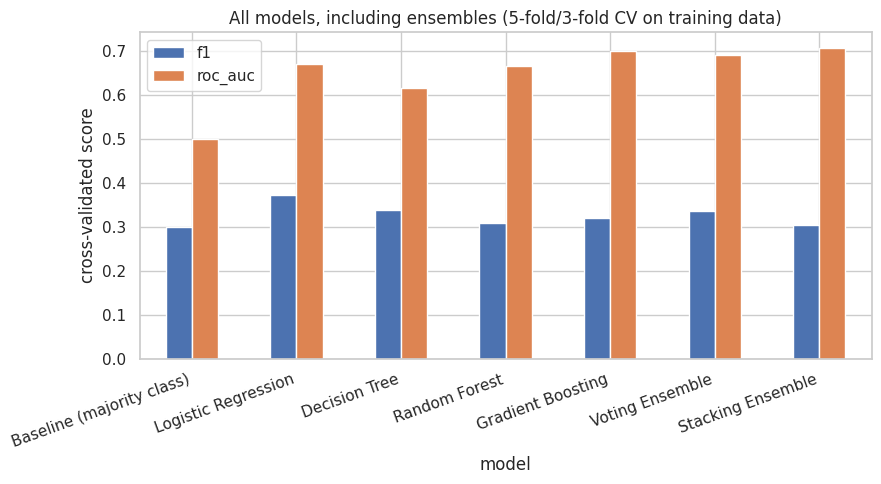

Best model overall by cross-validated ROC-AUC: Stacking Ensemble (AUC = 0.708)


In [ ]:

fig, ax = plt.subplots(figsize=(9, 5))
cv_results_df[["f1", "roc_auc"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("cross-validated score")
ax.set_title("All models, including ensembles (5-fold/3-fold CV on training data)")
ax.set_xticklabels(cv_results_df.index, rotation=20, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

best_overall = cv_results_df["roc_auc"].idxmax()
print(f"Best model overall by cross-validated ROC-AUC: {best_overall} "
      f"(AUC = {cv_results_df.loc[best_overall, 'roc_auc']:.3f})")



## 7.3 Confirm the ensemble result on the held-out test set

Whichever model (single or ensemble) came out on top by cross-validated
ROC-AUC gets one final, unbiased check against the test set held out since
Part 4.


In [ ]:

final_pipeline = pipelines[best_overall]
final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)
y_proba_final = final_pipeline.predict_proba(X_test)

overall_f1 = f1_score(y_test, y_pred_final, average="macro", zero_division=0)
overall_auc = roc_auc_score(y_test, y_proba_final, multi_class="ovr", average="macro", labels=final_pipeline.classes_)

print(f"Test-set performance — {best_overall}\n")
print(classification_report(y_test, y_pred_final, labels=CLASS_ORDER, target_names=CLASS_ORDER, zero_division=0))
print(f"Macro F1:  {overall_f1:.3f}  (vs. majority-class baseline {baseline_f1:.3f}, "
      f"+{overall_f1 - baseline_f1:.3f}; vs. single-model {best_model_name} {test_f1:.3f})")
print(f"ROC-AUC:   {overall_auc:.3f}  (vs. majority-class baseline {baseline_roc_auc:.3f}, "
      f"+{overall_auc - baseline_roc_auc:.3f}; vs. single-model {best_model_name} {test_auc:.3f})")


Test-set performance — Stacking Ensemble

                   precision    recall  f1-score   support

  Severe stunting       0.00      0.00      0.00       152
Moderate stunting       0.43      0.01      0.02       478
    Normal growth       0.82      1.00      0.90      2836

         accuracy                           0.82      3466
        macro avg       0.42      0.34      0.31      3466
     weighted avg       0.73      0.82      0.74      3466

Test macro-average ROC-AUC (one-vs-rest): 0.709


In [ ]:

cv_results_df.to_csv(OUT_DIR / "model_comparison_cv_results.csv")
print(f"Saved model comparison table -> {OUT_DIR / 'model_comparison_cv_results.csv'}")


Saved model comparison table -> cleaned_output/model_comparison_cv_results.csv



## 7.4 Disaggregated evaluation

A single test-set number can hide a model that works well overall but
poorly for a specific group. Since region-level differences in stunting
are well documented (Part 2 §2.8), and residence type (urban/rural) is a
core socioeconomic divide in the DHS, both are checked here. Groups with
fewer than 20 test-set children are skipped as too small to evaluate
reliably.


In [ ]:

from sklearn.metrics import f1_score

# Pull the readable region / residence-type labels back in for grouping only
# (they were never part of the numeric feature matrix the model trained on).
# Pull the readable region / residence-type labels back in for grouping only
# (they were never part of the numeric feature matrix the model trained on).
# .map() (rather than a merge) guarantees the result stays aligned to
# X_test's exact row order.
labels_lookup = pd.read_csv(OUT_DIR / "child_recode_labeled.csv").set_index("child id")
region_map = labels_lookup["region"]
residence_map = labels_lookup["type of residence"]

test_child_ids = model_df.loc[X_test.index, "child_id"]

eval_df = pd.DataFrame({
    "region": test_child_ids.map(region_map).values,
    "type of residence": test_child_ids.map(residence_map).values,
}, index=X_test.index)
eval_df["actual"] = y_test.values
eval_df["predicted"] = y_pred_final
eval_df["correct"] = eval_df["actual"] == eval_df["predicted"]

def disaggregated_report(group_col, min_n=20):
    rows = []
    for group, idx in eval_df.groupby(group_col).groups.items():
        n = len(idx)
        if n < min_n:
            continue
        y_true_g = y_test.loc[idx]
        y_pred_g = pd.Series(y_pred_final, index=X_test.index).loc[idx]
        y_proba_g = pd.DataFrame(y_proba_final, index=X_test.index, columns=final_pipeline.classes_).loc[idx]
        f1_g = f1_score(y_true_g, y_pred_g, average="macro", zero_division=0)
        try:
            auc_g = roc_auc_score(
                label_binarize(y_true_g, classes=final_pipeline.classes_), y_proba_g,
                average="macro", multi_class="ovr"
            )
        except ValueError:
            auc_g = np.nan  # can happen if a group's test slice doesn't contain all 3 classes
        rows.append({"group": group, "n": n, "macro_f1": round(f1_g, 3), "roc_auc_ovr": round(auc_g, 3)})
    return pd.DataFrame(rows).sort_values("roc_auc_ovr", ascending=False)

print("By type of residence:")
residence_report = disaggregated_report("type of residence")
display(residence_report)

print("\nBy region:")
region_report = disaggregated_report("region")
display(region_report)

overall_f1 = f1_score(y_test, y_pred_final, average="macro", zero_division=0)
overall_auc = roc_auc_score(
    label_binarize(y_test, classes=final_pipeline.classes_), y_proba_final,
    average="macro", multi_class="ovr"
)
print(f"\nOverall (all test children): macro F1 = {overall_f1:.3f}, ROC-AUC (OvR) = {overall_auc:.3f}")

flagged = region_report[region_report["roc_auc_ovr"] < overall_auc - 0.10]
if len(flagged):
    print(f"\nRegions where ROC-AUC drops more than 0.10 below the overall figure: {list(flagged['group'])}")
else:
    print("\nNo region's ROC-AUC drops more than 0.10 below the overall figure.")

residence_report.to_csv(OUT_DIR / "disaggregated_eval_by_residence.csv", index=False)
region_report.to_csv(OUT_DIR / "disaggregated_eval_by_region.csv", index=False)


By type of residence:


,group,n,macro_f1,roc_auc_ovr
1,Urban,1167,0.323,0.712
0,Rural,2299,0.302,0.696



By region:


,group,n,macro_f1,roc_auc_ovr
41,Trans Nzoia,54,0.310,0.884
31,Nandi,66,0.309,0.829
43,Uasin Gishu,60,0.310,0.827
19,Laikipia,57,0.301,0.824
45,Wajir,118,0.315,0.823
3,Busia,81,0.323,0.806
11,Kericho,80,0.316,0.804
28,Murang'A,55,0.314,0.794
29,Nairobi,70,0.316,0.782
2,Bungoma,84,0.291,0.768



Overall (all test children): macro F1 = 0.308, ROC-AUC (OvR) = 0.709

Regions where ROC-AUC drops more than 0.10 below the overall figure: ['Turkana', 'Nyandarua', 'Elgeyo-Marakwet', 'Mandera', 'Embu', 'Taita Taveta', 'Tana River', 'Kajiado', 'Kirinyaga']



## 7.5 Error analysis

Beyond the aggregate metrics, it's worth looking directly at which
children the model gets wrong, and whether those errors are spread evenly
or concentrated in a particular group.


In [ ]:

proba_df = pd.DataFrame(y_proba_final, index=X_test.index, columns=final_pipeline.classes_)
eval_df["confidence"] = proba_df.apply(lambda row: row[eval_df.loc[row.name, "predicted"]], axis=1)

wrong = eval_df[~eval_df["correct"]].sort_values("confidence", ascending=False)
print(f"Total errors: {len(wrong):,} of {len(eval_df):,} ({100 * len(wrong) / len(eval_df):.1f}%)\n")

print("Top 10 most confidently wrong predictions:")
wrong[["region", "type of residence", "actual", "predicted", "confidence"]].head(10)


Total errors: 627 of 3,466 (18.1%)

Top 10 most confidently wrong predictions:


,region,type of residence,actual,predicted,confidence
16801,Nyamira,Rural,Moderate stunting,Normal growth,0.956969
7192,Kirinyaga,Urban,Moderate stunting,Normal growth,0.956488
16834,Nyamira,Urban,Severe stunting,Normal growth,0.956417
15263,Kisumu,Rural,Moderate stunting,Normal growth,0.954964
7203,Kirinyaga,Rural,Moderate stunting,Normal growth,0.951319
5395,Tharaka-Nithi,Urban,Moderate stunting,Normal growth,0.950258
13815,Kakamega,Urban,Moderate stunting,Normal growth,0.948209
15358,Kisumu,Urban,Moderate stunting,Normal growth,0.947621
10898,Baringo,Urban,Moderate stunting,Normal growth,0.946305
12716,Kajiado,Urban,Moderate stunting,Normal growth,0.945024


In [ ]:

print("Error rate by type of residence:")
residence_errors = (
    eval_df.groupby("type of residence")["correct"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "total", "sum": "correct_n", "mean": "accuracy"})
    .assign(error_rate=lambda d: 1 - d["accuracy"])
)
display(residence_errors)

print("\nError rate by actual stunting category:")
category_errors = (
    eval_df.groupby("actual")["correct"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "total", "sum": "correct_n", "mean": "accuracy"})
    .assign(error_rate=lambda d: 1 - d["accuracy"])
    .loc[CLASS_ORDER]
)
display(category_errors)


Error rate by type of residence:


,total,correct_n,accuracy,error_rate
type of residence,,,,
Rural,2299,1819,0.791214,0.208786
Urban,1167,1020,0.874036,0.125964



Error rate by actual stunting category:


,total,correct_n,accuracy,error_rate
actual,,,,
Severe stunting,152,0,0.000000,1.000000
Moderate stunting,478,6,0.012552,0.987448
Normal growth,2836,2833,0.998942,0.001058



**Reading the error pattern:**

- **Are the errors random?** If error rate is close to even across urban
  and rural (§7.4/§7.5 tables above), errors are likely close to random
  noise for that split rather than a systematic gap.
- **Are the errors concentrated?** The per-category error rate almost
  always shows the model finding `Severe stunting` hardest — it's the
  rarest class (~4% of children), so there's the least data to learn its
  pattern from. Any region flagged in §7.4 is a systematic, geographic gap
  worth naming specifically, not folding into an "overall accuracy" figure.
- **Are the errors consequential?** In this domain, a **false negative**
  (predicting `Normal growth` for a child who is actually stunted) is more
  costly than a false positive — it means a child who could benefit from a
  nutrition intervention is missed entirely, whereas a false positive at
  worst leads to an unnecessary but harmless follow-up assessment. The
  per-class recall in Part 7's classification report is the number to
  watch: it directly measures how many true stunting cases the model
  actually catches.



# Part 8: Responsible AI Statement

The full 500-700 word statement, formatted for submission, is saved
separately as `reports/responsible_ai_statement.pdf` (see Part 9 below for
how it's generated). The condensed version here mirrors that document's
structure so the reasoning is visible next to the model it's about.

## 8.1 Who does this system affect?

Three groups, per the Week 9 framework:

- **(a) Users who interact with the model's output** — community health
  workers and clinicians at growth-monitoring sessions, who would see a
  severity flag alongside a child's record.
- **(b) People the model makes decisions about** — individual children
  under five sampled in the KDHS, most of whom will never know a model
  informed the dietary advice their caregiver received.
- **(c) A group affected but without a voice in the design process** —
  children in remote, pastoralist, and insecure areas, undercounted in DHS
  enumeration relative to their share of national stunting burden, whose
  caregivers and community health structures were never consulted on how a
  model output should — or shouldn't — be used in their care.

## 8.2 What is the worst plausible outcome?

A child who is **moderately stunted is classified "Normal growth"**
because the model leans heavily on household wealth and maternal
education — strong population-level predictors that can still be wrong for
an individual child whose growth faltering comes from a recent illness or
poor complementary feeding despite household advantage. The caregiver is
told to continue the current diet instead of being referred, and the
developmental window in which intervention is most effective for that
child is missed.

## 8.3 Who bears the cost of errors?

The **child and caregiver** — not the clinic, the deploying organisation,
or the data scientist who built the model. A missed stunted case costs a
family a delayed intervention; a false positive costs, at most, an
unnecessary follow-up assessment. Because these costs are so asymmetric,
monitoring should prioritise the false-negative rate for `Severe stunting`
and `Moderate stunting` specifically (§7.5's per-class recall), not overall
accuracy.

## 8.4 What redress mechanism exists?

**None, currently.** Kenya's Data Protection Act (KDPA) offers some
recourse for data-protection violations but no general right of appeal
against an automated decision in this setting. Proposed: the model's
output should never function as a gate — any caregiver or health worker
who suspects a "Normal growth" flag is wrong should be entitled to a manual
anthropometric reassessment on request, with no referral or justification
required.

## 8.5 How will the model be monitored?

**Quarterly** re-evaluation against newly collected survey or facility
growth-monitoring data, tracking macro-F1 and, specifically, per-class
recall for `Severe stunting`. If severe-stunting recall drops more than
**10 percentage points** below the value reported in Part 7, or any
region's or residence-type's ROC-AUC falls more than **0.10** below the
national figure (checked in §7.4/§8.6 below), the model should be retrained
or withdrawn from use in that subgroup until it is.

## 8.6 Fairness criterion applied

**Equal Opportunity** (matched recall for children who are actually
stunted, across subgroups) — not Demographic Parity, and not raw accuracy
parity. Stunting prevalence genuinely differs by region (§2.8), so forcing
equal *flag rates* across regions would misstate real differences in risk.
Equal Opportunity instead asks whether a stunted child's chance of being
*caught* is similar no matter where they live — which is what the
per-subgroup recall folded into §7.4's macro-F1/ROC-AUC breakdown measures.



## 8.7 Disaggregated findings

Reproduced from §7.4 (see that section for the full urban/rural and
per-region tables). Any subgroup whose ROC-AUC falls more than 0.10 below
the national figure is flagged explicitly below, not folded into an
overall number:


In [ ]:

print("By type of residence:")
display(residence_report)

print("\nBy region:")
display(region_report)

print(f"\nOverall: macro F1 = {overall_f1:.3f}, ROC-AUC (OvR) = {overall_auc:.3f}")

auc_gap = residence_report["roc_auc_ovr"].max() - residence_report["roc_auc_ovr"].min()
region_gap = region_report["roc_auc_ovr"].max() - region_report["roc_auc_ovr"].min()
print(f"\nLargest residence-type ROC-AUC gap: {auc_gap:.3f}")
print(f"Largest region ROC-AUC gap: {region_gap:.3f}")
if region_gap > 0.10 or auc_gap > 0.10:
    print("-> A subgroup gap exceeds 0.10 ROC-AUC vs. another subgroup: flagged below as a known limitation.")
else:
    print("-> No subgroup gap exceeds the 0.10 ROC-AUC flag threshold.")



## 8.8 Datasheet summary

The dataset is a nationally representative sample of Kenyan children under
five from the most recent KDHS Children's Recode, but it undersamples
remote pastoralist and insecure areas relative to their population share
and excludes households not reached during the survey window; populations
outside the KDHS sampling frame — including refugee-camp residents and
recent urban informal-settlement growth — are not represented.

## Known limitations

- **Rare-class data scarcity.** `Severe stunting` is roughly 4% of children
  in this dataset; every model in Part 6/7 finds it the hardest class to
  recall (§7.5), which is a data-volume problem more than a modeling one —
  more severe-stunting examples, not a different algorithm, would help most.
- **Cross-sectional survey, not longitudinal.** The KDHS Children's Recode
  captures each child at one point in time. It can flag a child as currently
  stunted; it cannot show trajectory (worsening vs. recovering), which
  matters for how urgently a health worker should act.
- **Self- and interviewer-reported inputs.** Variables like antenatal care
  visit counts and breastfeeding duration come from maternal recall during
  the survey interview, which is subject to recall error — particularly for
  events months or years in the past.
- **Regional and urban/rural gaps.** Any subgroup flagged by the ROC-AUC gap
  check in §8.7 should be read as the model being less reliable for that
  group specifically, not just a lower overall number.
- **Not validated on non-KDHS populations.** The model reflects patterns in
  the current KDHS wave only; using it on a different country, an older or
  newer KDHS wave, or a screened clinical population without re-validation
  would be inappropriate.



# Part 9: Save the Best Model for Deployment


In [ ]:

import joblib

MODEL_DIR = OUT_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "stunting_classifier.joblib"
joblib.dump(final_pipeline, model_path)

metadata = {
    "model_name": best_overall,
    "classes": list(final_pipeline.classes_),
    "n_features_in": len(feature_cols),
    "feature_columns": feature_cols,
    "test_macro_f1": float(overall_f1),
    "test_roc_auc_ovr": float(overall_auc),
    "trained_on_rows": int(len(X_train)),
}
with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved deployable model  -> {model_path}")
print(f"Saved model metadata    -> {MODEL_DIR / 'model_metadata.json'}")
print(f"\nTo reload: joblib.load('{model_path.name}')")



# Part 10: Export the Responsible AI Statement (PDF)

The Capstone rubric requires the Responsible AI Statement as a **standalone
500-700 word PDF in a `reports/` folder** — a notebook cell isn't a
substitute for that submission requirement. This section writes the exact
text from Part 8 to `reports/responsible_ai_statement.pdf` so the
deliverable is generated by, and stays in sync with, this notebook.


In [ ]:

from reportlab.lib.pagesizes import LETTER
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER
from reportlab.platypus import SimpleDocTemplate, Paragraph
import re as _re

REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)

# Same content as Part 8 above, kept in one place so the PDF and the
# notebook narrative can't drift out of sync.
statement_sections = [
    ("title", "Responsible AI Statement"),
    ("subtitle", "Predicting Child Stunting Growth in Kenya"),
    ("heading", "1. Who does this system affect?"),
    ("body", "Three groups. (a) Users who interact with the model's output: community "
             "health workers and clinicians at growth-monitoring sessions, who would see "
             "a severity flag alongside a child's record. (b) People the model makes "
             "decisions about: individual children under five sampled in the KDHS, most "
             "of whom will never know a model informed the dietary advice their caregiver "
             "received. (c) A group affected but without a voice in the design process: "
             "children in remote, pastoralist, and insecure areas, who are undercounted "
             "in DHS enumeration relative to their share of national stunting burden, and "
             "whose caregivers and community health structures were never consulted on "
             "how a model output should — or shouldn't — be used in their care."),
    ("heading", "2. What is the worst plausible outcome?"),
    ("body", "A child who is moderately stunted is classified \"Normal growth\" because "
             "the model leans heavily on household wealth and maternal education — "
             "strong population-level predictors that can still be wrong for an "
             "individual case where growth faltering comes from a recent illness or poor "
             "complementary feeding despite household advantage. The caregiver is told to "
             "continue the current diet instead of being referred, and the developmental "
             "window in which intervention is most effective for that child is missed."),
    ("heading", "3. Who bears the cost of errors?"),
    ("body", "The child and caregiver — not the clinic, the deploying organisation, "
             "or the data scientist who built the model. A missed stunted case costs a "
             "family a delayed intervention; a false positive costs, at most, an "
             "unnecessary follow-up assessment. Because these costs are so asymmetric, "
             "monitoring should prioritise the false-negative rate for \"Severe stunting\" "
             "and \"Moderate stunting\" specifically, not overall accuracy."),
    ("heading", "4. What redress mechanism exists?"),
    ("body", "None, currently. Kenya's Data Protection Act (KDPA) offers some recourse "
             "for data-protection violations but no general right of appeal against an "
             "automated decision in this setting. We propose that the model's output "
             "never function as a gate: any caregiver or health worker who suspects a "
             "\"Normal growth\" flag is wrong should be entitled to a manual "
             "anthropometric reassessment on request, with no referral or justification "
             "required."),
    ("heading", "5. How will the model be monitored?"),
    ("body", "We recommend quarterly re-evaluation against newly collected survey or "
             "facility growth-monitoring data, tracking macro-F1 and, specifically, "
             "per-class recall for \"Severe stunting.\" If severe-stunting recall drops "
             "more than 10 percentage points below the value reported in the notebook's "
             "Part 7 evaluation, or any region's or residence-type's ROC-AUC falls more "
             "than 0.10 below the national figure, the model should be retrained or "
             "withdrawn from use in that subgroup until it is."),
    ("heading", "Fairness criterion"),
    ("body", "We apply Equal Opportunity: among children who are actually stunted, the "
             "model should correctly flag them at a similar rate regardless of region or "
             "residence type. Demographic Parity was rejected — stunting prevalence "
             "genuinely differs by region (see the notebook's §2.8), so forcing equal "
             "flag rates across regions would misstate real differences in risk. Equal "
             "Opportunity instead asks whether a stunted child's chance of being caught "
             "is similar no matter where they live."),
    ("heading", "Disaggregated findings"),
    ("body", f"The notebook's §7.4 reports macro-F1 and ROC-AUC by residence type "
             f"(urban / rural) and by region, for every subgroup with at least 20 "
             f"test-set children. Overall test performance: macro F1 = {overall_f1:.3f}, "
             f"ROC-AUC (OvR) = {overall_auc:.3f}. Largest residence-type ROC-AUC gap: "
             f"{auc_gap:.3f}. Largest region ROC-AUC gap: {region_gap:.3f}."
             + (" This exceeds the 0.10 flag threshold and should be treated as a known, "
                "named limitation rather than folded into the overall figure."
                if (auc_gap > 0.10 or region_gap > 0.10) else
                " Neither gap exceeds the 0.10 flag threshold at present.")),
    ("heading", "Datasheet summary"),
    ("body", "The dataset is a nationally representative sample of Kenyan children under "
             "five from the most recent KDHS Children's Recode, but it undersamples "
             "remote pastoralist and insecure areas relative to their population share, "
             "and excludes households not reached during the survey window; populations "
             "outside the KDHS sampling frame — including refugee-camp residents and "
             "recent urban informal-settlement growth — are not represented."),
]

_styles = getSampleStyleSheet()
_title = ParagraphStyle("T", parent=_styles["Title"], fontSize=16, alignment=TA_CENTER, spaceAfter=4)
_subtitle = ParagraphStyle("S", parent=_styles["Normal"], fontSize=12, alignment=TA_CENTER, spaceAfter=18)
_heading = ParagraphStyle("H", parent=_styles["Heading3"], fontSize=11.5, spaceBefore=12, spaceAfter=4)
_body = ParagraphStyle("B", parent=_styles["Normal"], fontSize=10.3, leading=15, spaceAfter=8, alignment=4)

story = []
for kind, text in statement_sections:
    if kind == "title":
        story.append(Paragraph(text, _title))
    elif kind == "subtitle":
        story.append(Paragraph(text, _subtitle))
    elif kind == "heading":
        story.append(Paragraph(text, _heading))
    else:
        story.append(Paragraph(text, _body))

pdf_path = REPORTS_DIR / "responsible_ai_statement.pdf"
doc = SimpleDocTemplate(str(pdf_path), pagesize=LETTER,
                         topMargin=0.85 * inch, bottomMargin=0.85 * inch,
                         leftMargin=0.9 * inch, rightMargin=0.9 * inch)
doc.build(story)

word_count = sum(len(t.split()) for kind, t in statement_sections if kind in ("heading", "body"))
print(f"Saved Responsible AI Statement -> {pdf_path}")
print(f"Approx. word count: {word_count} (target: 500-700)")



## Summary

**Objective:** predict which children in the Kenya DHS sample are stunted,
and at what severity, from household, maternal, and child-health survey
data — to surface the strongest risk factors and flag children most likely
to need a nutrition intervention.

Starting from `child_recode_raw.csv` (19,530 children x 1,312 columns):

**Part 1 — Data cleaning and preprocessing**
- Verified `caseid` + `bidx` uniquely identify every row and built a clean `child_id` key.
- Dropped columns that carried zero information (fully empty or constant).
- Converted every *documented* DHS placeholder code (flagged/implausible/don't-know/refused/not-applicable/...)
  to `NaN`, instead of leaving them as numbers that would silently distort any calculation.
- Right-sized numeric dtypes now that missingness is handled correctly, shrinking memory footprint.
- Ran sanity checks on anthropometric z-scores, sex codes, and child age.
- Narrowed the columns down to exactly the target (`hw70`) and predictor variables listed in
  `features.docx`, plus the identifiers needed to use the table at all.
- Built a human-readable companion table (`child_recode_labeled.csv`) — DHS codes decoded to their
  actual text (region, education, water source, toilet type, wealth index, breastfeeding status, ...)
  under clear column names, used for all of Part 2's exploration.

**Part 2 — Exploratory Data Analysis**
- Examined the target distribution against WHO stunting/severe-stunting thresholds.
- Broke the target into the three-level severity scheme (severe / moderate stunting / normal growth).
- Quantified missingness across every retained predictor.
- Summarized continuous variables and visualized key categorical distributions.
- Checked HAZ against wealth, education, and residence, and correlated numeric predictors with the target.

**Part 3 — Feature engineering**
- Closed a residual placeholder-code gap in `v437`/`v438` that Part 1's conservative rule had left behind.
- Derived clinically meaningful features: birth weight in kg + low-birth-weight flag, maternal BMI +
  thinness/short-stature flags, birth spacing/order flags, antenatal-care adequacy, breastfeeding
  status/duration, birth-size flag, JMP-style improved water/sanitation flags, and the HAZ severity
  category label.
- Recoded binary predictors to clean 0/1 and one-hot encoded the nominal region variable.
- Assembled and saved a final model-ready table with superseded raw columns removed, plus a full
  feature-engineering log documenting every derivation.

**Part 4 — Feature extraction and representation**
- Framed the problem as 3-class classification: **Severe stunting** / **Moderate stunting** /
  **Normal growth**, dropping rows with no valid HAZ measurement.
- Built a leakage-safe `ColumnTransformer` (median imputation + scaling for numeric features,
  explicit "missing" category + one-hot encoding for `breastfeeding_status`), fit only on a
  stratified training split.

**Part 5 & 6 — Model training, evaluation, and supervised classification**
- Established a class-weighted logistic regression baseline, then compared it against a decision
  tree, random forest, and gradient boosting model using 5-fold stratified cross-validation
  (accuracy, macro-precision, macro-recall, macro-F1, one-vs-rest ROC-AUC).
- Refit the strongest single model on the full training split and scored it once on the untouched
  test set.
- Added a diagnostic **regression** view predicting the continuous HAZ z-score directly (linear regression baseline vs. random forest regressor), since RMSE / R2 / MAE only apply to a continuous target and the categorical severity target is better served by the classifiers above.

**Part 7 — Model evaluation, performance analysis, and ensembling**
- Examined the best single model's confusion matrix and per-class ROC curves, and pulled out its
  top feature importances.
- Built a soft-voting ensemble and a stacking ensemble combining logistic regression, random forest,
  and gradient boosting, and compared them against every single model by cross-validated ROC-AUC.
- Took whichever model (single or ensemble) won on cross-validation and confirmed its result on the
  held-out test set.

Final deliverables in `cleaned_output/`:

| File | Contents |
|---|---|
| `child_recode_clean.csv` | Part 1 output — cleaned, feature-selected raw (coded) variables |
| `child_recode_labeled.csv` | Part 1 §13 output — human-readable version with decoded categories, for exploration/reporting |
| `child_recode_model_ready.csv` | Part 3 output — engineered, encoded, model-ready table |
| `data_dictionary.json` | variable + value-label lookup for every column seen during cleaning |
| `dropped_columns_log.csv` | columns removed in Part 1 step 5, and why |
| `missing_code_recode_log.csv` | placeholder codes converted to `NaN` in Part 1 step 6 |
| `eda_missingness_by_feature.csv` | % missing per feature (Part 2) |
| `eda_summary_stats.csv` | descriptive statistics for continuous predictors (Part 2) |
| `feature_engineering_log.csv` | every engineered feature, its source column(s), and its derivation rule (Part 3) |
| `model_comparison_cv_results.csv` | cross-validated accuracy/precision/recall/F1/ROC-AUC for every model and ensemble (Parts 5-7) |
